<a href="https://colab.research.google.com/github/whatiddone/Dart_B_4th/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚢 TITANIC에서 살아남기

## connection to google account

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# 코렙 한글깨짐 방지
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 데이터 시각화에 사용할 라이브러리
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# 브라우저에서 바로 그려지도록
%matplotlib inline

# 그래프에 retina display 적용
%config InlineBackend.figure_format = 'retina'

# 유니코드에서  음수 부호설정
mpl.rc('axes', unicode_minus=False)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 29 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 3s (3,783 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 125044 files and dire

In [ ]:
import matplotlib.font_manager as fm  # 폰트 관련 용도
import matplotlib.pyplot as plt
import matplotlib as mpl
fm.findSystemFonts() # 설치된 폰트 확인
!apt-get update -qq
!apt-get install fonts-nanum* -qq
sys_font=fm.findSystemFonts()
nanum_font = [f for f in sys_font if 'Nanum' in f]
nanum_font
fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', # ttf 파일이 저장되어 있는 경로
    name='NanumGothic')                        # 이 폰트의 원하는 이름 설정
fm.fontManager.ttflist.insert(0, fe)              # Matplotlib에 폰트 추가
plt.rcParams["font.family"] = 'NanumGothic'     # NanumGothic으로 글꼴 설정
mpl.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 출력되도록 설정

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum-coding.
(Reading database ... 125067 files and directories currently installed.)
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-eco.
Preparing to unpack .../fonts-nanum-eco_1.000-7_all.deb ...
Unpacking fonts-nanum-eco (1.000-7) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-coding (2.5-3) ...
Setting up fonts-nanum-eco (1.000-7) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
import easydict
args = easydict.EasyDict()

# path 정보
args.default_path = '/content/drive/MyDrive/DArtB/Titanic/'
args.train_csv = args.default_path+'train.csv' #위의 파일 경로에다가 추가 경로만 덧붙이는 거. 이런 것이 가능하다라는 것을 알기
args.test_csv = args.default_path+'test.csv'
args.default_submission_csv = args.default_path+'submission.csv'

args.submission_csv = args.default_path+'result/submission.csv'
args.save_results = args.default_path+"result/model_results.json"

# 데이터 분석을 위한 변수들
args.random_state = 42
args.results = []

#easydict 라이브러리를 사용하여 간단한 설정 및 변수들을 정의하고 초기화하는 작업을 수행

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')
plt.ion()

import warnings
warnings.filterwarnings('ignore')

In [ ]:
ori_train = pd.read_csv(args.train_csv)
ori_test = pd.read_csv(args.test_csv)
submission = pd.read_csv(args.default_submission_csv)

## 데이터 기본 정보 확인

- Surived:0=사망, 1=생존
- Pclass: 1=1등석, 2=2등석, 3=3등석
- gender:male=남성, female=여성
- Age: 나이
- SibSp: 타이타닉 호에 동승한 자매/배우자의 수
- Parch: 타이타닉 호에 동승한 부모/자식의 수
- Ticket: 티켓 번호
- Fare: 승객 요금
- Cabin: 방 호수
- Embarked: 탑승지; C=셰르부르, Q=퀴즈타운, S=사우샘프턴

In [ ]:
print(ori_train.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:
print(ori_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


## 데이터 분포 시각화

### 연속형 변수

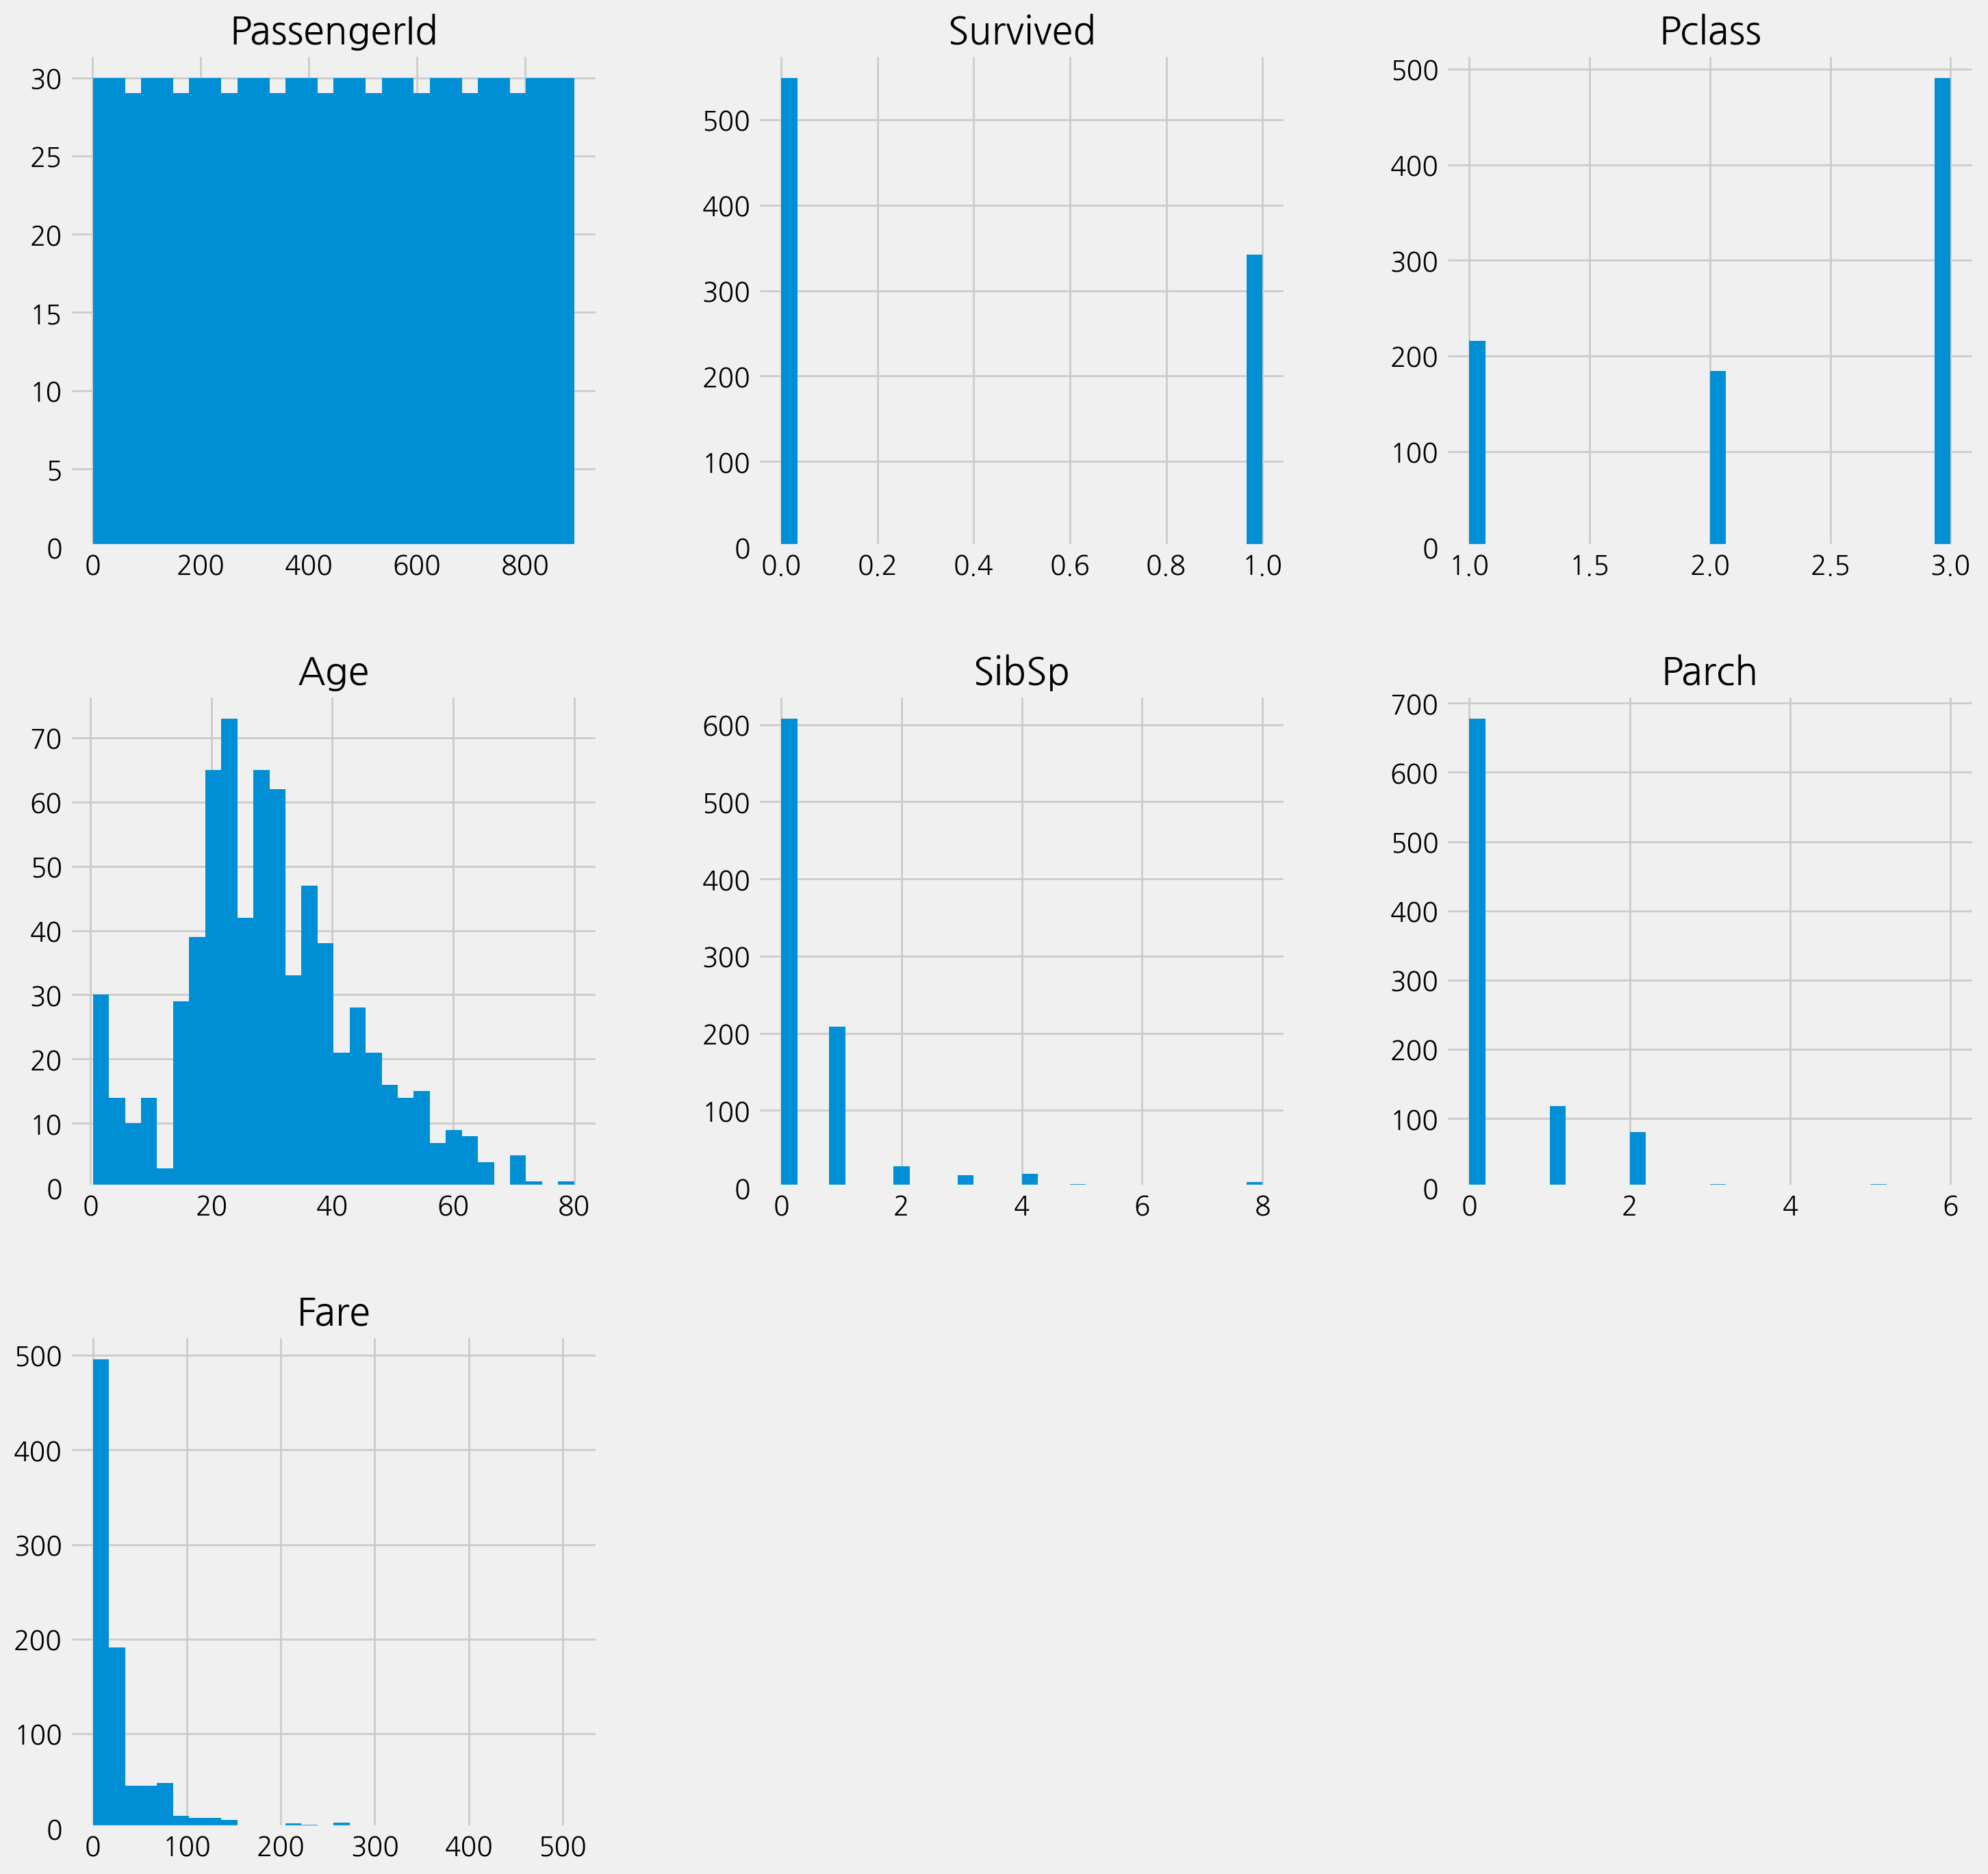

In [ ]:
# 히스토그램 (연속형 변수의 분포 확인)
ori_train.hist(figsize=(16, 16), bins=30)
plt.show()

### 범주형 변수

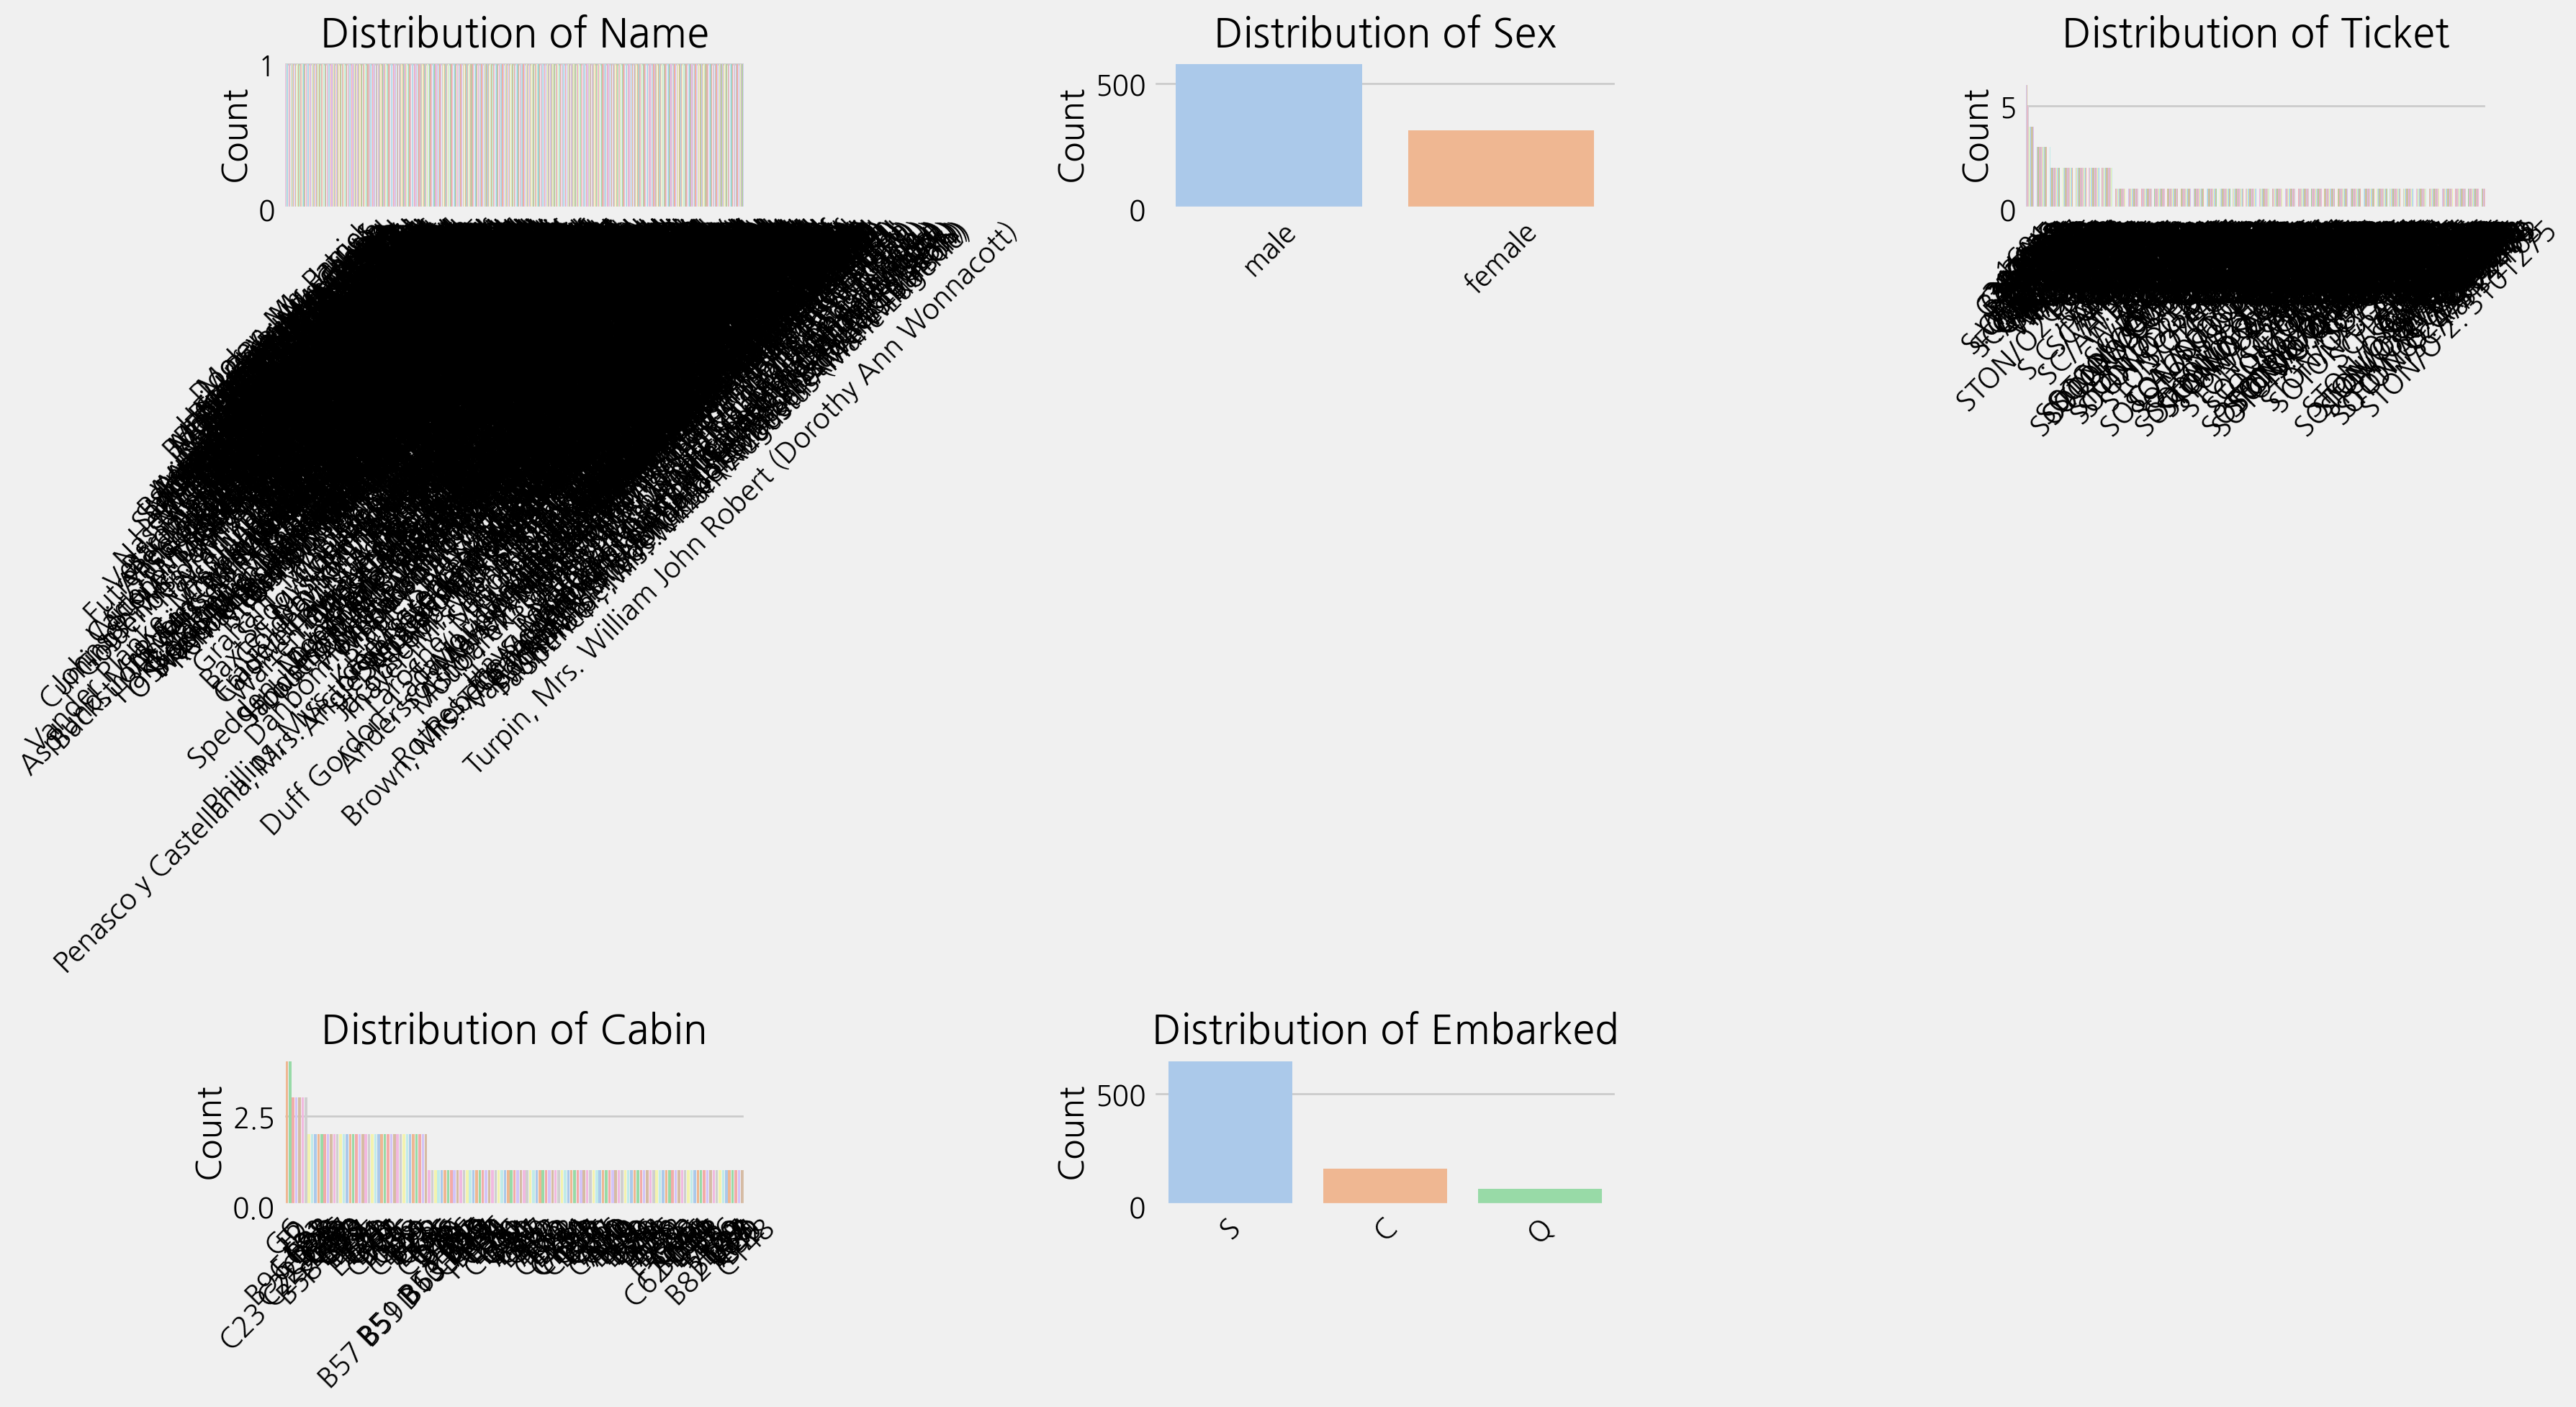

In [ ]:
# 범주형 변수에 대한 분포 시각화

categorical_cols = ori_train.select_dtypes(include=['object']).columns.tolist()
num_cats = len(categorical_cols)
num_cols = 3  # 한 행에 3개씩 표시
num_rows = (num_cats // num_cols) + (num_cats % num_cols > 0)  # 필요한 행 수 계산

# 시각화
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(18, num_rows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=ori_train, x=col, ax=axes[i], palette="pastel", order=ori_train[col].value_counts().index)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

# 남는 subplot 숨기기
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

피처 엔지니어링 단계에서 PassengerId, Name, Ticket은 Drop하기, Sex, Embarked 같은 경우는 범주 간 위계가 없기 때문에 원-핫 인코딩

# EDA

### 결측치 확인

In [ ]:
# train 결측치
missing_data = pd.DataFrame({
    "Missing Values": ori_train.isnull().sum(),
    "Percentage (%)": (ori_train.isnull().sum() / len(ori_train)) * 100
})
print(missing_data)

             Missing Values  Percentage (%)
PassengerId               0        0.000000
Survived                  0        0.000000
Pclass                    0        0.000000
Name                      0        0.000000
Sex                       0        0.000000
Age                     177       19.865320
SibSp                     0        0.000000
Parch                     0        0.000000
Ticket                    0        0.000000
Fare                      0        0.000000
Cabin                   687       77.104377
Embarked                  2        0.224467


In [ ]:
# test 결측치
missing_data = pd.DataFrame({
    "Missing Values": ori_test.isnull().sum(),
    "Percentage (%)": (ori_test.isnull().sum() / len(ori_test)) * 100
})
print(missing_data)

             Missing Values  Percentage (%)
PassengerId               0        0.000000
Pclass                    0        0.000000
Name                      0        0.000000
Sex                       0        0.000000
Age                      86       20.574163
SibSp                     0        0.000000
Parch                     0        0.000000
Ticket                    0        0.000000
Fare                      1        0.239234
Cabin                   327       78.229665
Embarked                  0        0.000000


train과 test 모두 Age와 Cabin에 많은 결측치 존재

## 데이터 분포 확인

### Pclass 별 Age

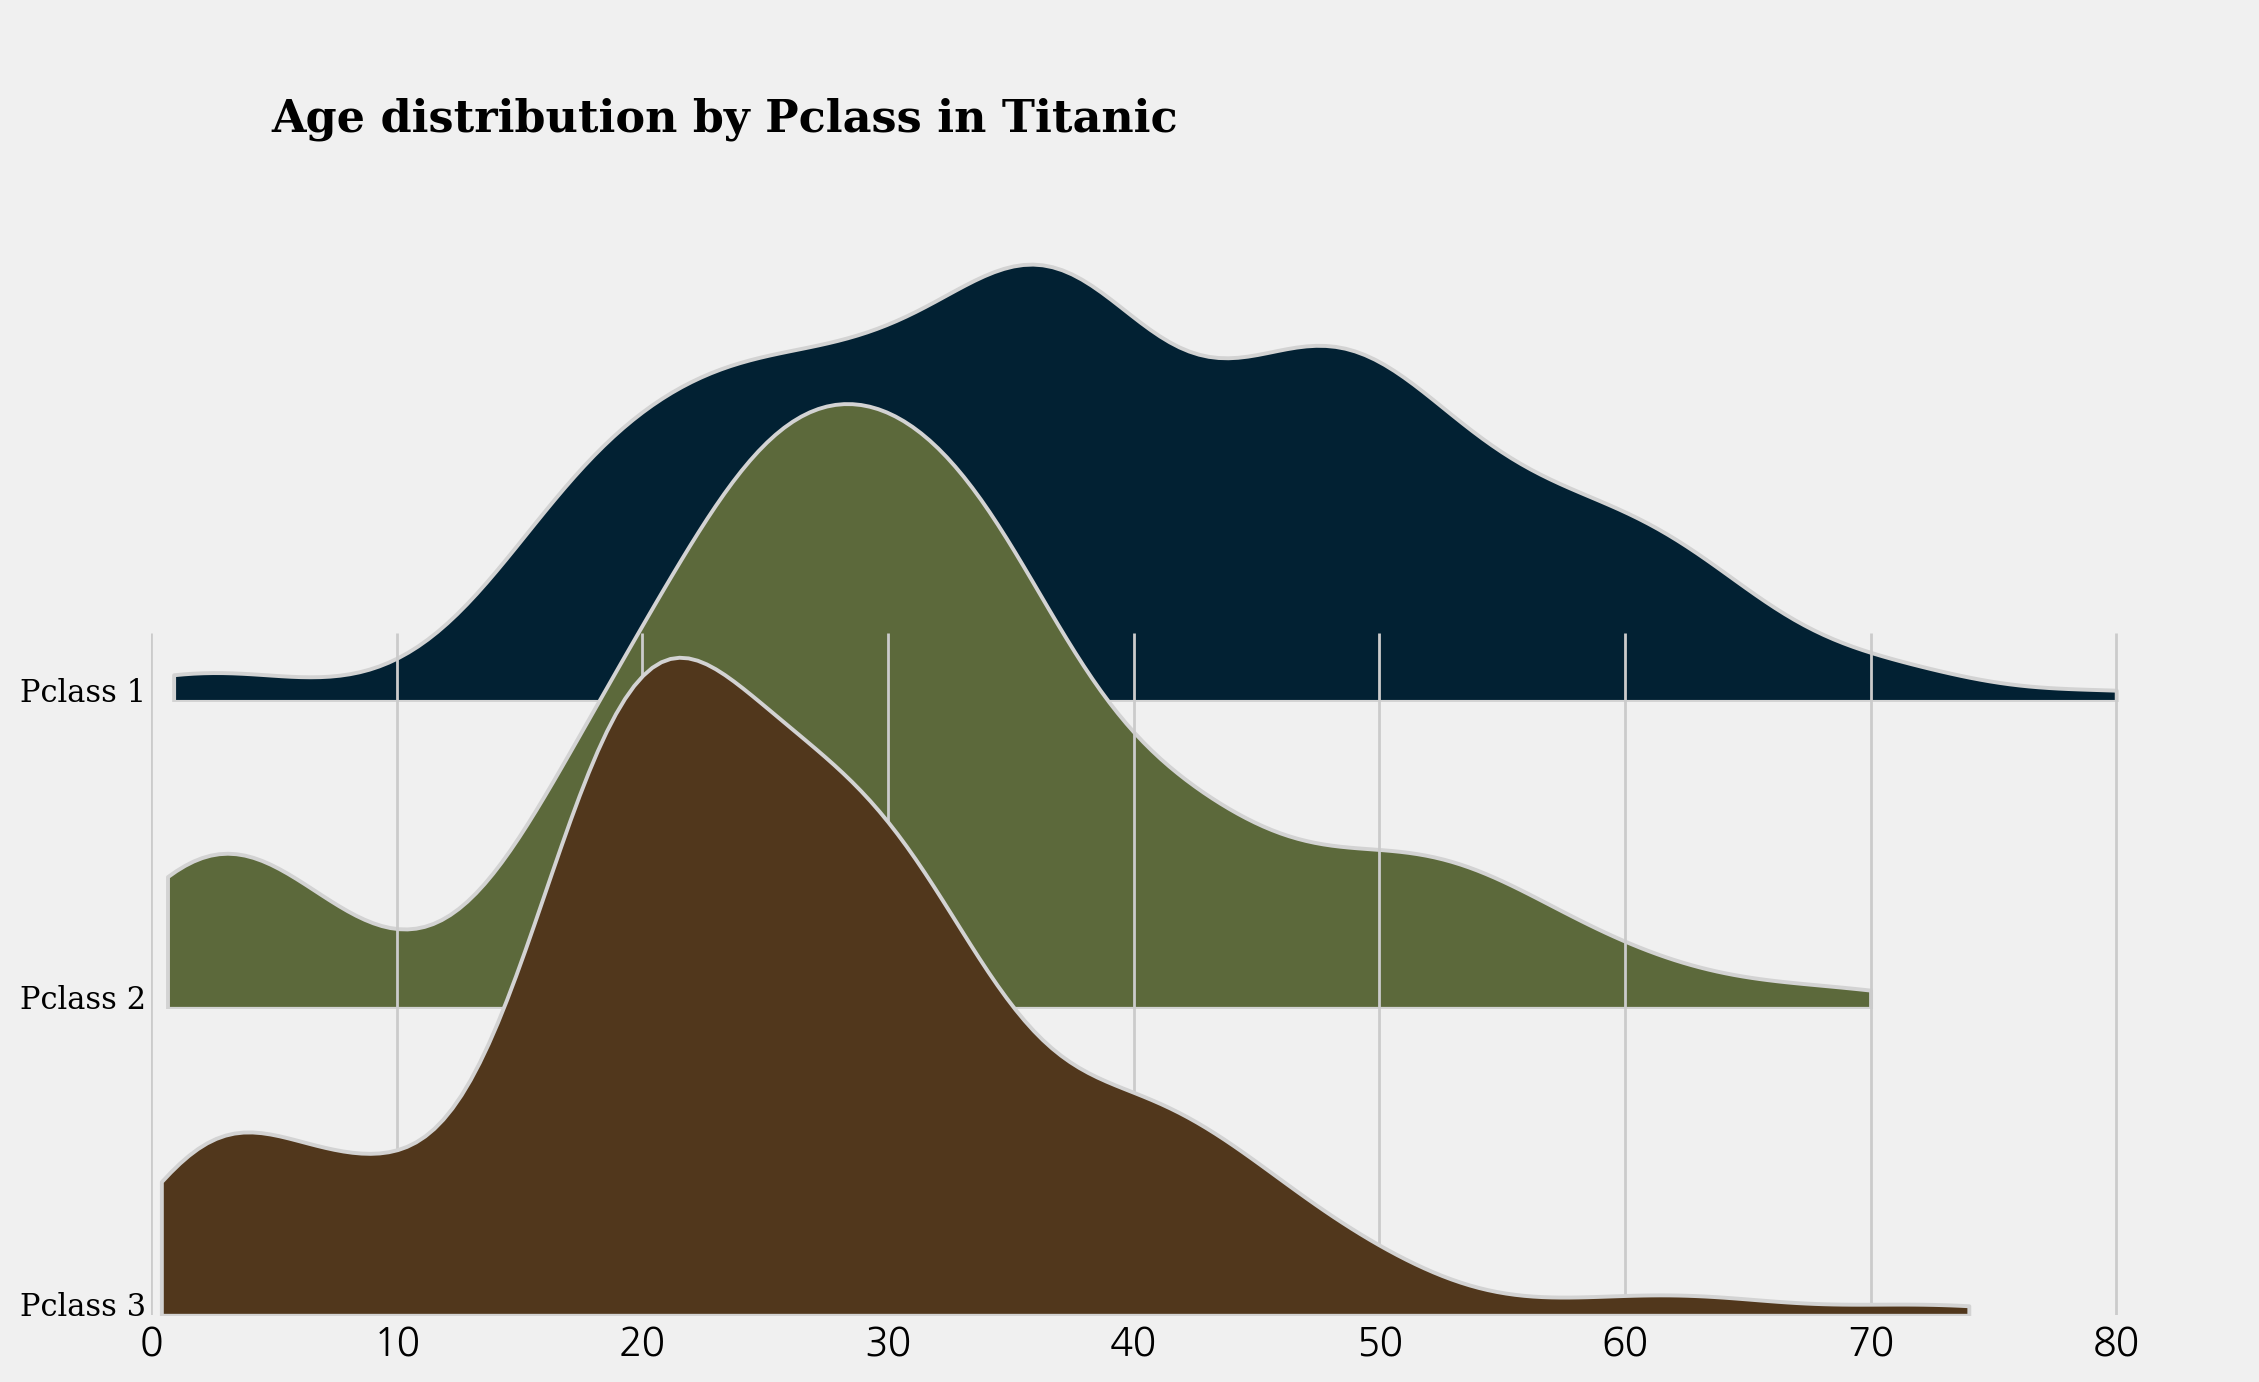

In [ ]:
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(3,1)
gs.update(hspace= -0.55)

axes = list()
colors = ["#022133", "#5c693b", "#51371c"]

for idx, cls, c in zip(range(3), sorted(ori_train['Pclass'].unique()), colors):
    axes.append(fig.add_subplot(gs[idx, 0]))

    # you can also draw density plot with matplotlib + scipy.
    sns.kdeplot(x='Age', data=ori_train[ori_train['Pclass']==cls],
                fill=True, ax=axes[idx], cut=0, bw_method=0.25,
                lw=1.4, edgecolor='lightgray',color=c, alpha=1)

    axes[idx].set_ylim(0, 0.04)
    axes[idx].set_xlim(0, 85)

    axes[idx].set_yticks([])
    if idx != 2 : axes[idx].set_xticks([])
    axes[idx].set_ylabel('')
    axes[idx].set_xlabel('')

    spines = ["top","right","left","bottom"]
    for s in spines:
        axes[idx].spines[s].set_visible(False)

    axes[idx].patch.set_alpha(0)
    axes[idx].text(-0.2,0,f'Pclass {cls}',fontweight="light", fontfamily='serif', fontsize=11,ha="right")

fig.text(0.13,0.81,"Age distribution by Pclass in Titanic", fontweight="bold", fontfamily='serif', fontsize=16)
plt.show()

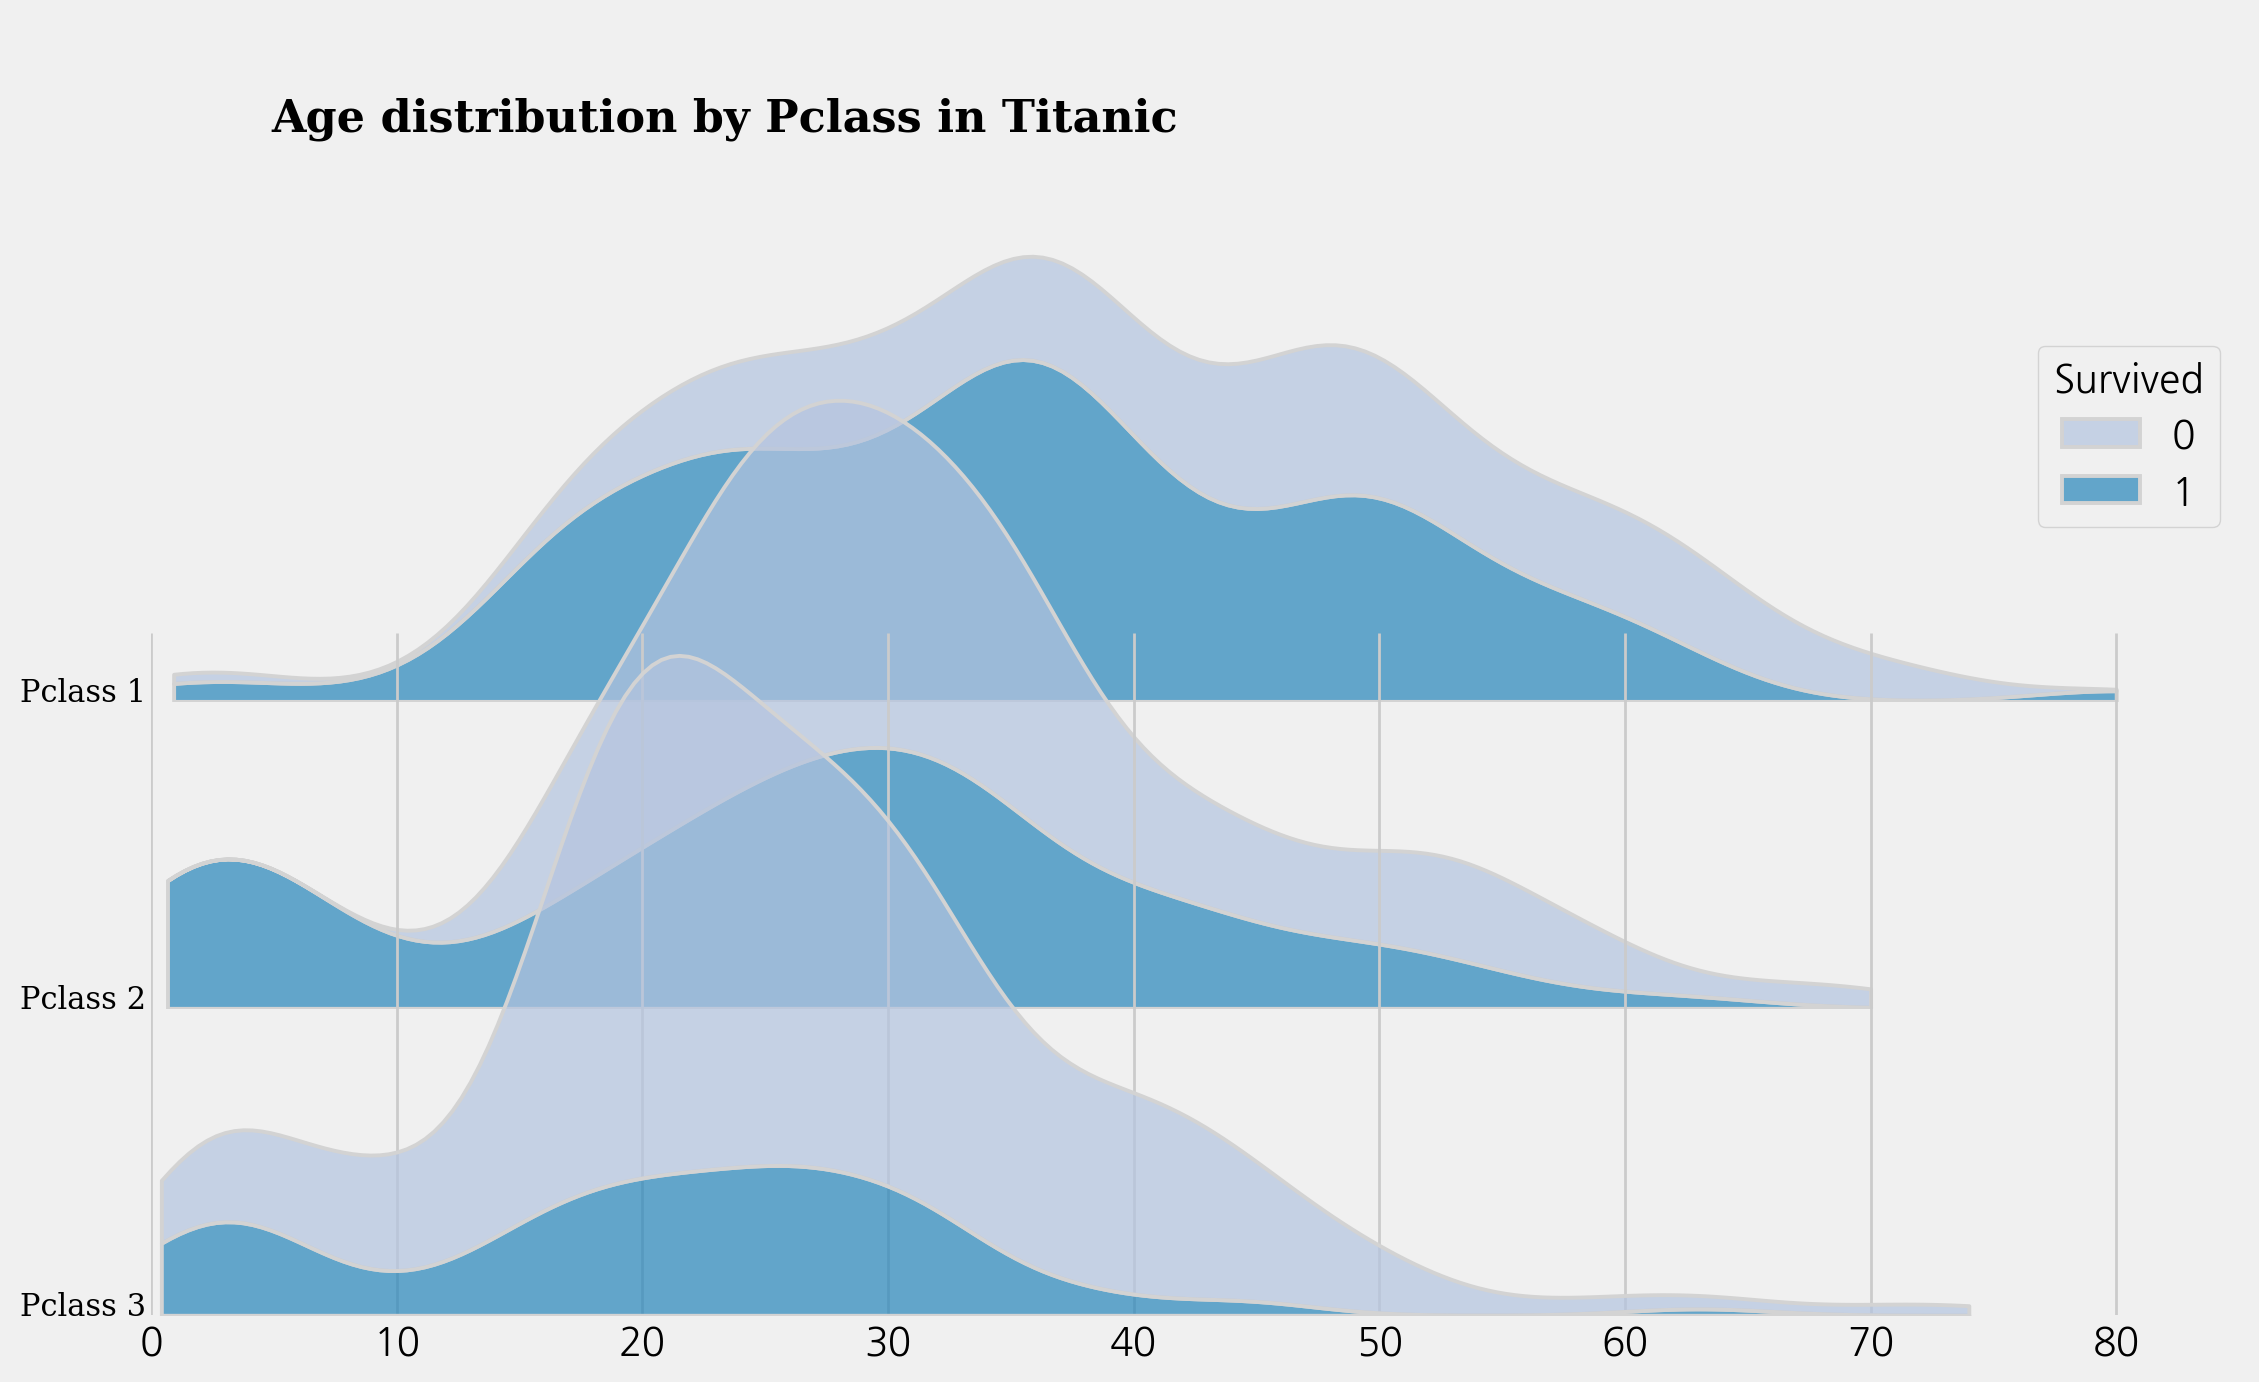

In [ ]:
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(3,1)
gs.update(hspace= -0.55)

axes = list()
colors = ["#022133", "#5c693b", "#51371c"]

for idx, cls, c in zip(range(3), sorted(ori_train['Pclass'].unique()), colors):
    axes.append(fig.add_subplot(gs[idx, 0]))

    # you can also draw density plot with matplotlib + scipy.
    sns.kdeplot(x='Age', data=ori_train[ori_train['Pclass']==cls],
                fill=True, ax=axes[idx], cut=0, bw_method=0.25,
                lw=1.4, edgecolor='lightgray', hue='Survived',
                multiple="stack", palette='PuBu', alpha=0.7
               )

    axes[idx].set_ylim(0, 0.04)
    axes[idx].set_xlim(0, 85)

    axes[idx].set_yticks([])
    if idx != 2 : axes[idx].set_xticks([])
    axes[idx].set_ylabel('')
    axes[idx].set_xlabel('')

    spines = ["top","right","left","bottom"]
    for s in spines:
        axes[idx].spines[s].set_visible(False)

    axes[idx].patch.set_alpha(0)
    axes[idx].text(-0.2,0,f'Pclass {cls}',fontweight="light", fontfamily='serif', fontsize=11,ha="right")
    if idx != 1 : axes[idx].get_legend().remove()

fig.text(0.13,0.81,"Age distribution by Pclass in Titanic", fontweight="bold", fontfamily='serif', fontsize=16)

plt.show()

### Pclass 별 Fare

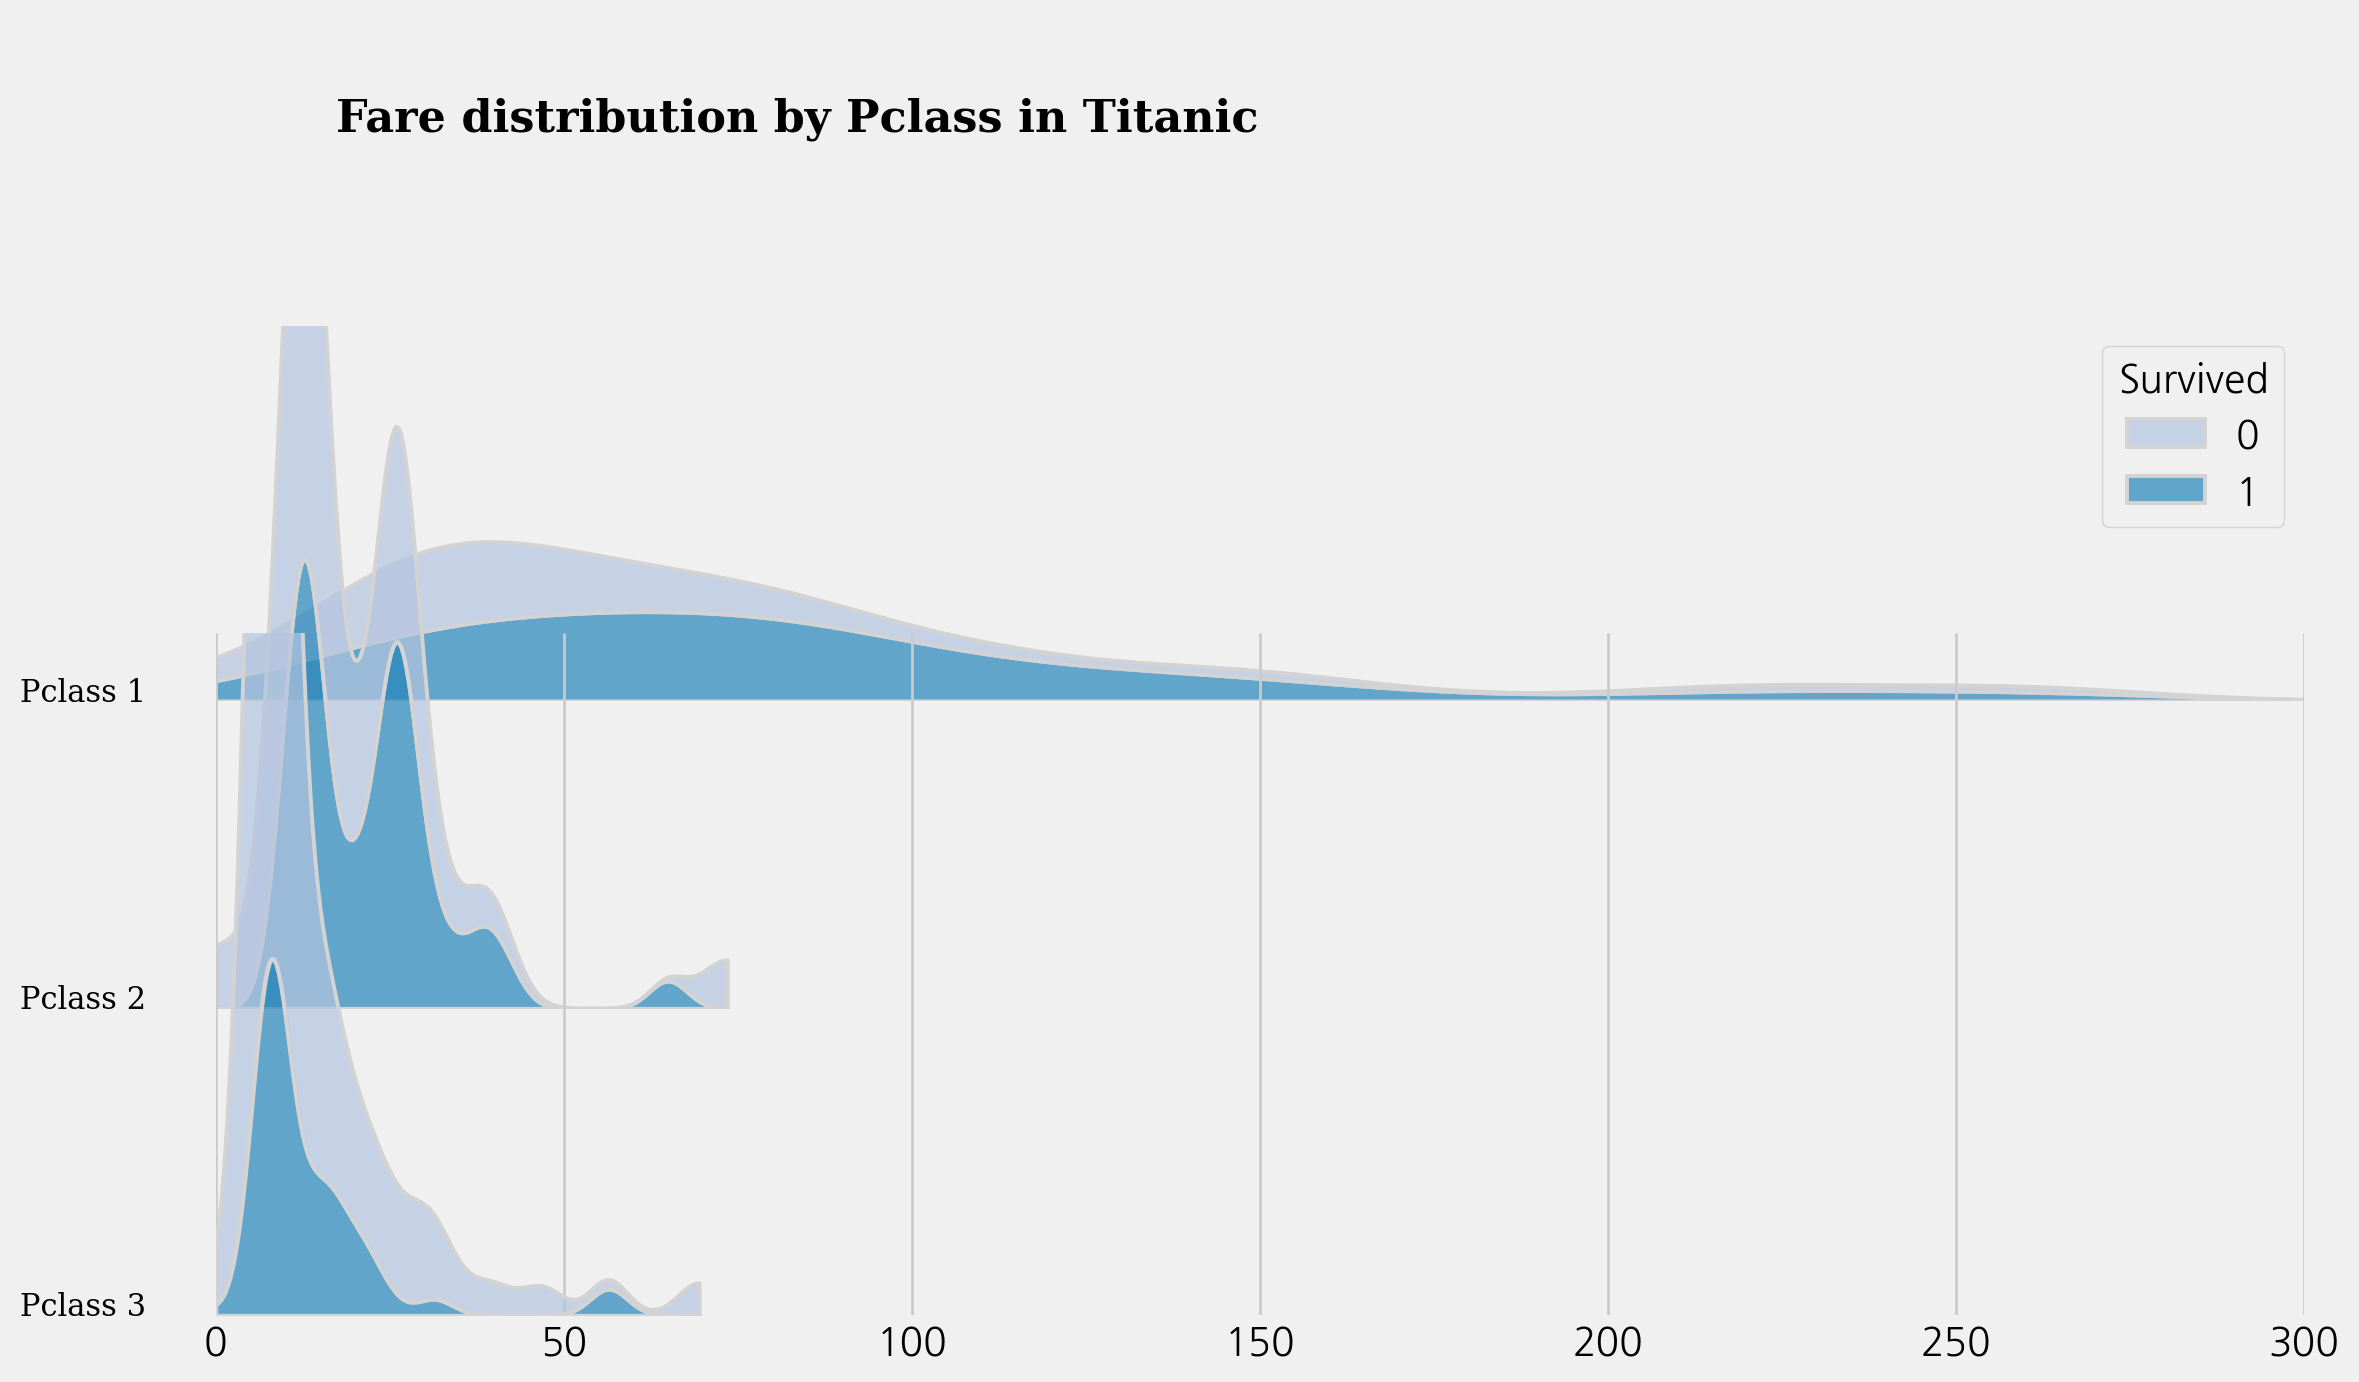

In [ ]:
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(3, 1)
gs.update(hspace=-0.55)

axes = list()
colors = ["#022133", "#5c693b", "#51371c"]

for idx, cls, c in zip(range(3), sorted(ori_train['Pclass'].unique()), colors):
    axes.append(fig.add_subplot(gs[idx, 0]))

    sns.kdeplot(
        x='Fare',
        data=ori_train[ori_train['Pclass'] == cls],
        fill=True,
        ax=axes[idx],
        cut=0,
        bw_method=0.25,
        lw=1.4,
        edgecolor='lightgray',
        hue='Survived',
        multiple="stack",
        palette='PuBu',
        alpha=0.7
    )

    axes[idx].set_ylim(0, 0.04)
    axes[idx].set_xlim(0, 300)  # Fare 값 분포가 커서 제한 걸어줌 (필요하면 조정 가능)

    axes[idx].set_yticks([])
    if idx != 2:
        axes[idx].set_xticks([])
    axes[idx].set_ylabel('')
    axes[idx].set_xlabel('')

    spines = ["top", "right", "left", "bottom"]
    for s in spines:
        axes[idx].spines[s].set_visible(False)

    axes[idx].patch.set_alpha(0)
    axes[idx].text(-10, 0, f'Pclass {cls}', fontweight="light", fontfamily='serif', fontsize=11, ha="right")

    if idx != 1:
        axes[idx].get_legend().remove()

fig.text(0.13, 0.81, "Fare distribution by Pclass in Titanic", fontweight="bold", fontfamily='serif', fontsize=16)

plt.show()


In [ ]:
from scipy import stats

# Pclass별 Fare 데이터 추출 (결측치 제거)
fare_p1 = ori_train[ori_train['Pclass'] == 1]['Fare'].dropna()
fare_p2 = ori_train[ori_train['Pclass'] == 2]['Fare'].dropna()
fare_p3 = ori_train[ori_train['Pclass'] == 3]['Fare'].dropna()

# ANOVA 수행
f_stat, p_val = stats.f_oneway(fare_p1, fare_p2, fare_p3)

print(f"ANOVA 결과 - F-statistic: {f_stat:.4f}, p-value: {p_val:.4f}")


ANOVA 결과 - F-statistic: 242.3442, p-value: 0.0000


In [ ]:
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey HSD 수행
tukey = pairwise_tukeyhsd(endog=ori_train['Fare'],     # 분석할 값
                          groups=ori_train['Pclass'],  # 그룹
                          alpha=0.05)

print(tukey)


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
     1      2 -63.4925   0.0 -72.9165 -54.0685   True
     1      3 -70.4791   0.0 -78.1489 -62.8094   True
     2      3  -6.9866 0.108 -15.1064   1.1331  False
-----------------------------------------------------


In [ ]:
from scipy.stats import ttest_ind

group1 = ori_train[ori_train['Pclass'] == 1]['Fare'].dropna()
group2 = ori_train[ori_train['Pclass'].isin([2,3])]['Fare'].dropna()

t_stat, p_val = ttest_ind(group1, group2, equal_var=False)  # Welch's t-test
print(f"T-test 결과 - t-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")


T-test 결과 - t-statistic: 12.8052, p-value: 0.0000


#### 2등석과 3등석은 하나의 그룹으로

In [ ]:
ori_train['Pclass_grouped'] = ori_train['Pclass'].apply(lambda x: 1 if x == 1 else 2)


### Age & Survival

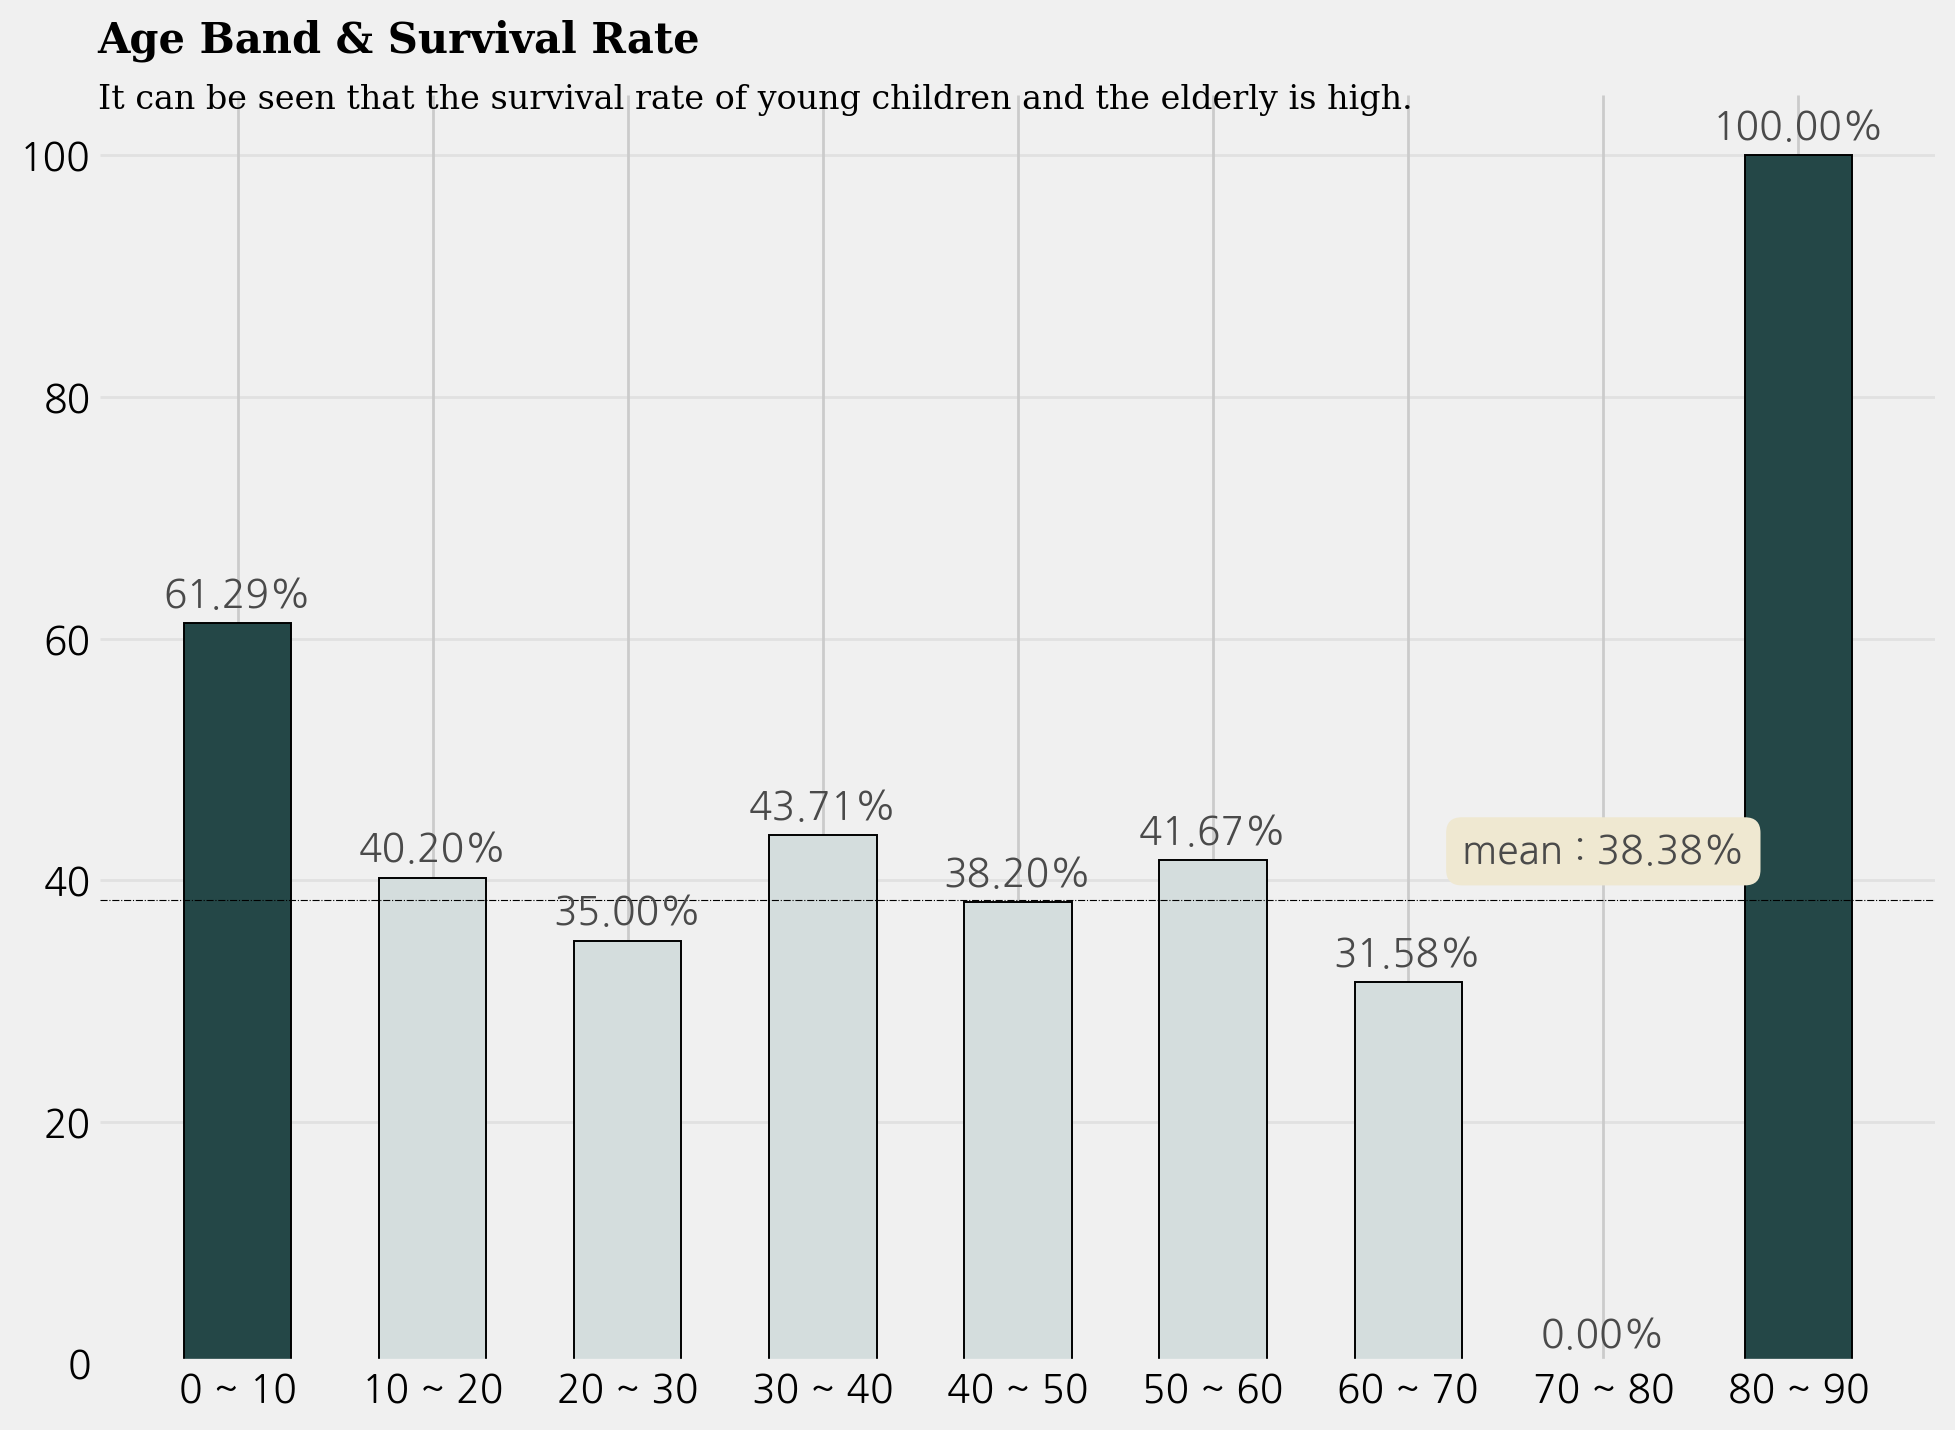

In [ ]:
def age_band(num):
    for i in range(1, 100):
        if num < 10*i :  return f'{(i-1) * 10} ~ {i*10}'

ori_train['age_band'] = ori_train['Age'].apply(age_band)
titanic_age = ori_train[['age_band', 'Survived']].groupby('age_band')['Survived'].value_counts().sort_index().unstack().fillna(0)
titanic_age['Survival rate'] = titanic_age[1] / (titanic_age[0] + titanic_age[1]) * 100

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

color_map = ['#d4dddd' for _ in range(9)]
color_map[0] = color_map[8] = '#244747' # color highlight

ax.bar(titanic_age['Survival rate'].index, titanic_age['Survival rate'],
       color=color_map, width=0.55,
       edgecolor='black',
       linewidth=0.7)

for s in ["top","right","left"]:
    ax.spines[s].set_visible(False)


# Annotation Part
for i in titanic_age['Survival rate'].index:
    ax.annotate(f"{titanic_age['Survival rate'][i]:.02f}%",
                   xy=(i, titanic_age['Survival rate'][i] + 2.3),
                   va = 'center', ha='center',fontweight='light',
                   color='#4a4a4a')


# mean line + annotation
mean = ori_train['Survived'].mean() *100
ax.axhline(mean ,color='black', linewidth=0.4, linestyle='dashdot')
ax.annotate(f"mean : {mean :.4}%",
            xy=('70 ~ 80', mean + 4),
            va = 'center', ha='center',
            color='#4a4a4a',
            bbox=dict(boxstyle='round', pad=0.4, facecolor='#efe8d1', linewidth=0))


# Title & Subtitle
fig.text(0.06, 1, 'Age Band & Survival Rate', fontsize=15, fontweight='bold', fontfamily='serif')
fig.text(0.06, 0.96, 'It can be seen that the survival rate of young children and the elderly is high.', fontsize=12, fontweight='light', fontfamily='serif')

grid_y_ticks = np.arange(0, 101, 20)
ax.set_yticks(grid_y_ticks)
ax.grid(axis='y', linestyle='-', alpha=0.4)

plt.tight_layout()
plt.show()

80대 이상이면 100퍼 생존

### Sibsp & Survival

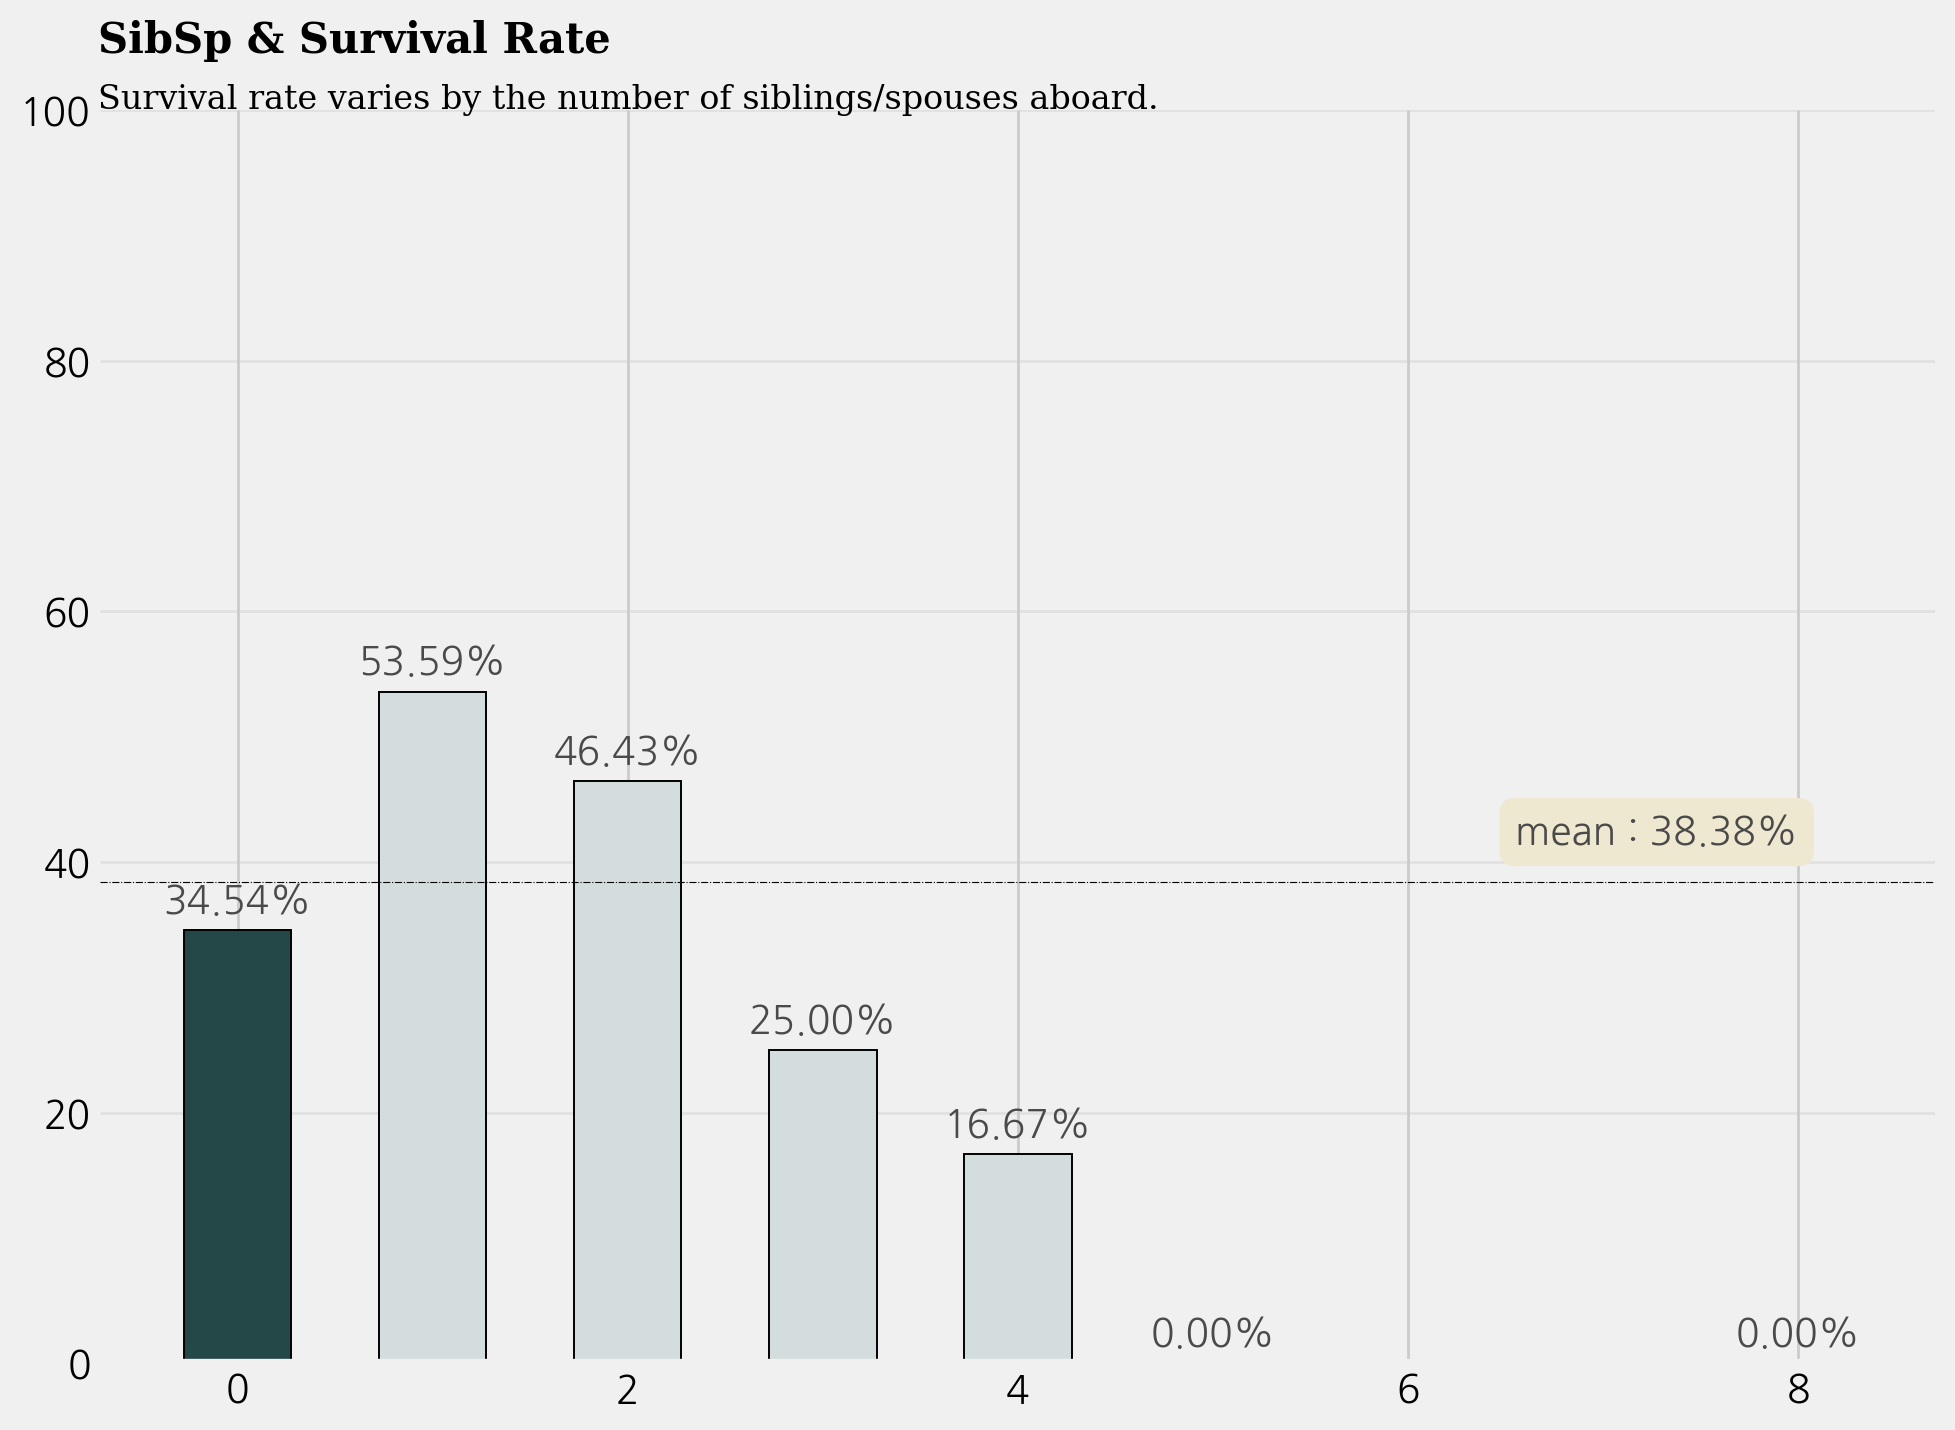

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# SibSp 별 생존자 수 및 비율 계산
titanic_sibsp = ori_train[['SibSp', 'Survived']].groupby('SibSp')['Survived'].value_counts().sort_index().unstack().fillna(0)
titanic_sibsp['Survival rate'] = titanic_sibsp[1] / (titanic_sibsp[0] + titanic_sibsp[1]) * 100

# 시각화
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# 색상 설정 (처음과 마지막 값 강조)
color_map = ['#d4dddd' for _ in range(len(titanic_sibsp))]
color_map[0] = color_map[-1] = '#244747'  # 첫 번째와 마지막 값 강조

ax.bar(titanic_sibsp.index, titanic_sibsp['Survival rate'],
       color=color_map, width=0.55,
       edgecolor='black',
       linewidth=0.7)

# 테두리 제거
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)

# 값 라벨 추가
for i in titanic_sibsp.index:
    ax.annotate(f"{titanic_sibsp['Survival rate'][i]:.02f}%",
                xy=(i, titanic_sibsp['Survival rate'][i] + 2.3),
                va='center', ha='center', fontweight='light',
                color='#4a4a4a')

# 평균 생존률 라인 추가
mean = ori_train['Survived'].mean() * 100
ax.axhline(mean, color='black', linewidth=0.4, linestyle='dashdot')
ax.annotate(f"mean : {mean:.2f}%",
            xy=(max(titanic_sibsp.index), mean + 4),
            va='center', ha='right',
            color='#4a4a4a',
            bbox=dict(boxstyle='round', pad=0.4, facecolor='#efe8d1', linewidth=0))

# 제목 & 설명
fig.text(0.06, 1, 'SibSp & Survival Rate', fontsize=15, fontweight='bold', fontfamily='serif')
fig.text(0.06, 0.96, 'Survival rate varies by the number of siblings/spouses aboard.',
         fontsize=12, fontweight='light', fontfamily='serif')

# y축 설정
grid_y_ticks = np.arange(0, 101, 20)
ax.set_yticks(grid_y_ticks)
ax.grid(axis='y', linestyle='-', alpha=0.4)

plt.tight_layout()
plt.show()


### Parch & Survival

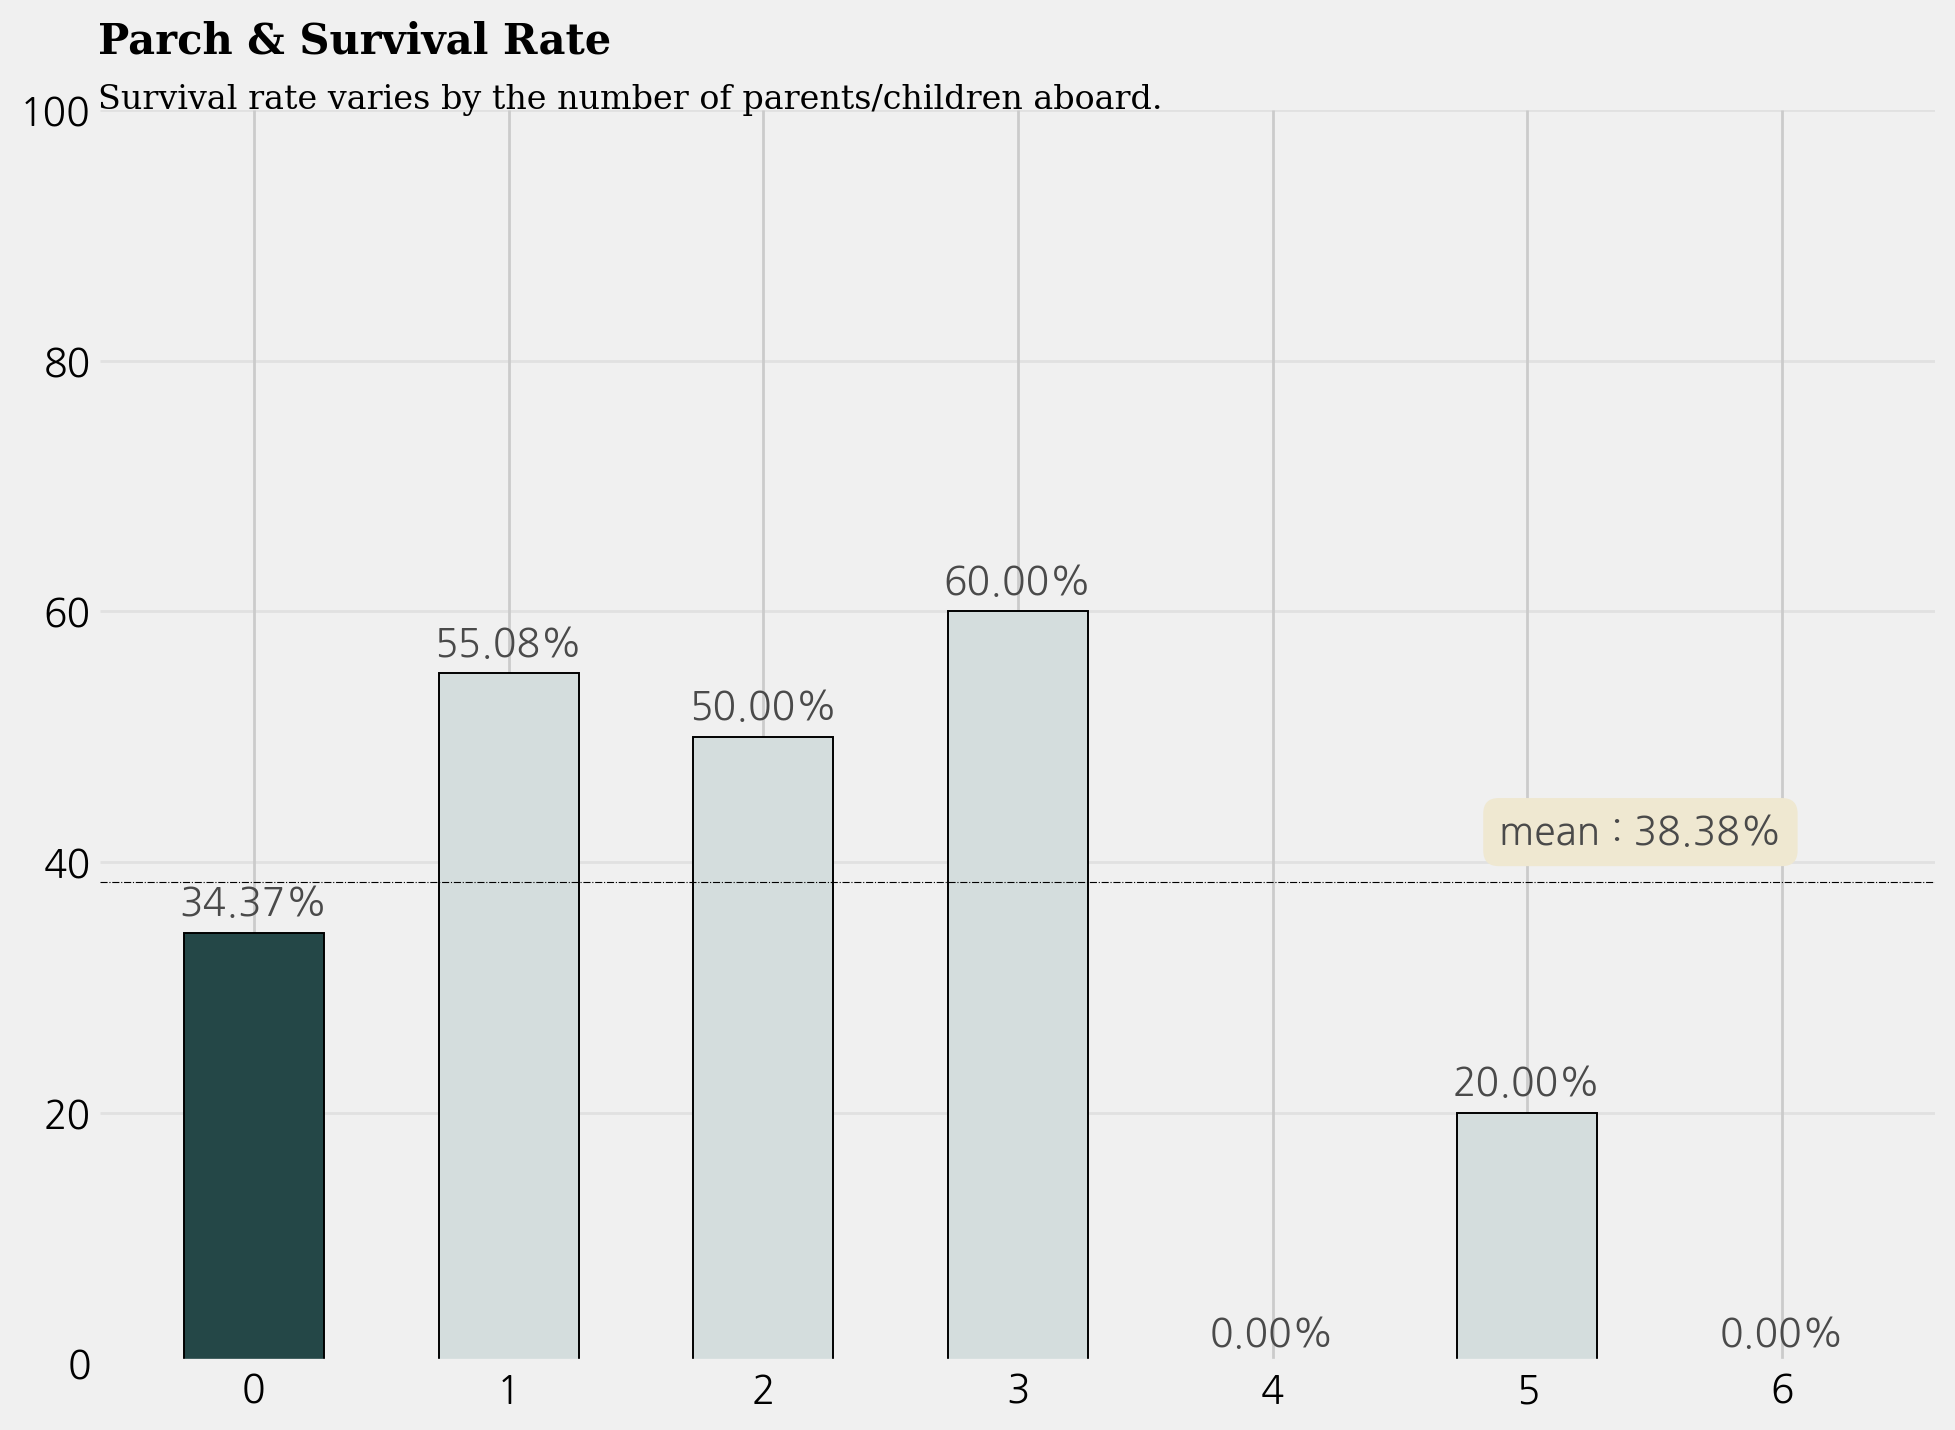

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Parch 별 생존자 수 및 비율 계산
titanic_parch = ori_train[['Parch', 'Survived']].groupby('Parch')['Survived'].value_counts().sort_index().unstack().fillna(0)
titanic_parch['Survival rate'] = titanic_parch[1] / (titanic_parch[0] + titanic_parch[1]) * 100

# 시각화
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# 색상 설정 (처음과 마지막 값 강조)
color_map = ['#d4dddd' for _ in range(len(titanic_parch))]
color_map[0] = color_map[-1] = '#244747'  # color highlight

ax.bar(titanic_parch.index, titanic_parch['Survival rate'],
       color=color_map, width=0.55,
       edgecolor='black',
       linewidth=0.7)

# 테두리 제거
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)

# 값 라벨 추가
for i in titanic_parch.index:
    ax.annotate(f"{titanic_parch['Survival rate'][i]:.02f}%",
                xy=(i, titanic_parch['Survival rate'][i] + 2.3),
                va='center', ha='center', fontweight='light',
                color='#4a4a4a')

# 평균 생존률 라인 추가
mean = ori_train['Survived'].mean() * 100
ax.axhline(mean, color='black', linewidth=0.4, linestyle='dashdot')
ax.annotate(f"mean : {mean:.2f}%",
            xy=(max(titanic_parch.index), mean + 4),
            va='center', ha='right',
            color='#4a4a4a',
            bbox=dict(boxstyle='round', pad=0.4, facecolor='#efe8d1', linewidth=0))

# 제목 & 설명
fig.text(0.06, 1, 'Parch & Survival Rate', fontsize=15, fontweight='bold', fontfamily='serif')
fig.text(0.06, 0.96, 'Survival rate varies by the number of parents/children aboard.',
         fontsize=12, fontweight='light', fontfamily='serif')

# y축 설정
grid_y_ticks = np.arange(0, 101, 20)
ax.set_yticks(grid_y_ticks)
ax.grid(axis='y', linestyle='-', alpha=0.4)

plt.tight_layout()
plt.show()


### Survival by Gender

In [ ]:
survival_rate = ori_train.groupby(['Sex'])['Survived'].mean()
survival_rate

,Survived
Sex,
female,0.742038
male,0.188908


In [ ]:
male_rate = survival_rate.loc['male']
female_rate = survival_rate.loc['female']

male_pos = np.random.uniform(0, male_rate, len(ori_train[(ori_train['Sex']=='male') & (ori_train['Survived']==1)]))
male_neg = np.random.uniform(male_rate, 1, len(ori_train[(ori_train['Sex']=='male') & (ori_train['Survived']==0)]))
female_pos = np.random.uniform(0, female_rate, len(ori_train[(ori_train['Sex']=='female') & (ori_train['Survived']==1)]))
female_neg = np.random.uniform(female_rate, 1, len(ori_train[(ori_train['Sex']=='female') & (ori_train['Survived']==0)]))

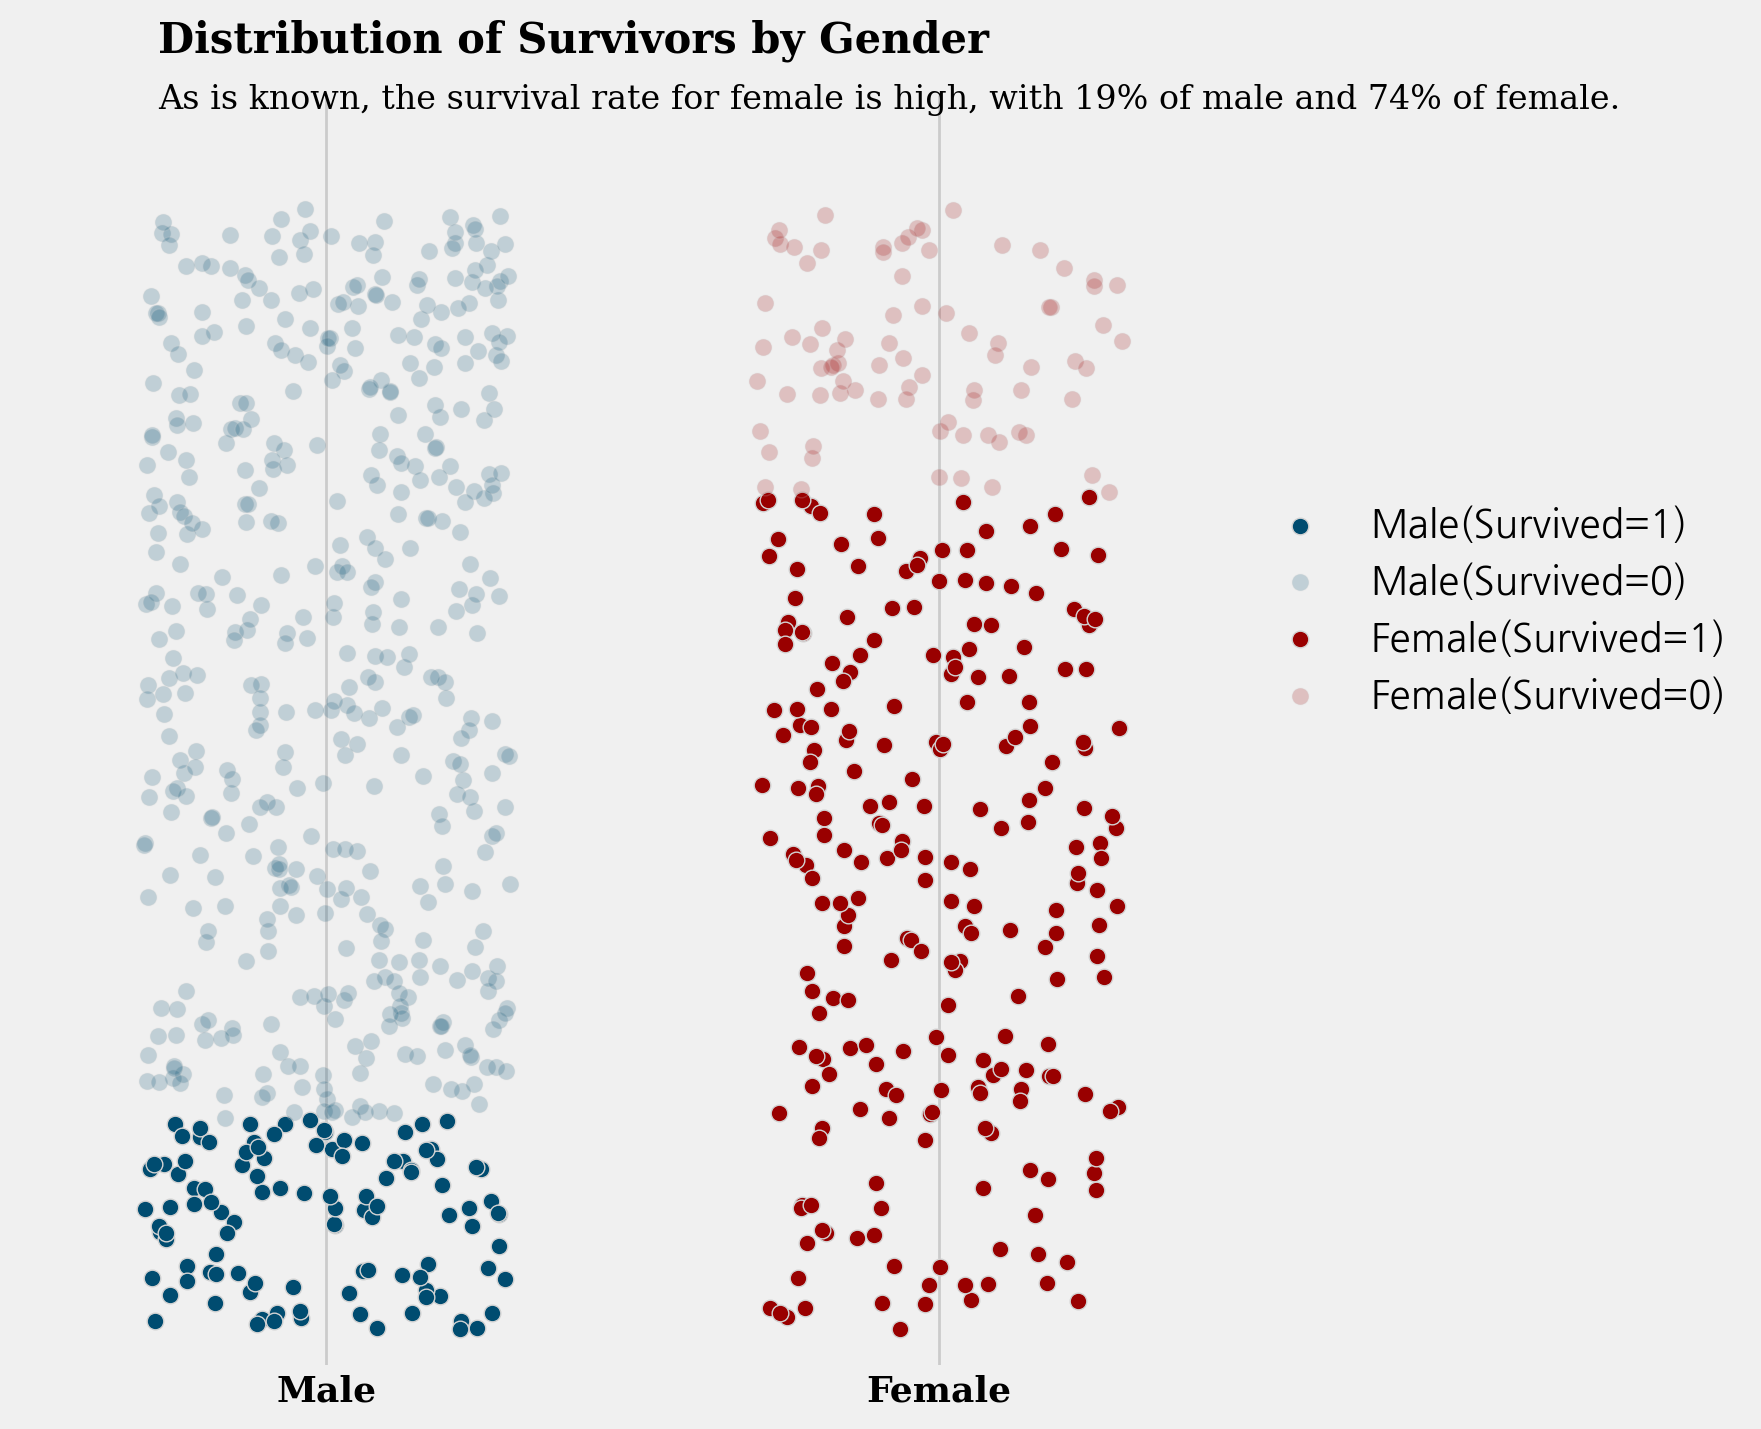

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

np.random.seed(42)

# Male Stripplot
ax.scatter(np.random.uniform(-0.3, 0.3, len(male_pos)), male_pos, color='#004c70', edgecolor='lightgray', label='Male(Survived=1)')
ax.scatter(np.random.uniform(-0.3, 0.3, len(male_neg)), male_neg, color='#004c70', edgecolor='lightgray', alpha=0.2, label='Male(Survived=0)')

# Female Stripplot
ax.scatter(1+np.random.uniform(-0.3, 0.3, len(female_pos)), female_pos, color='#990000', edgecolor='lightgray', label='Female(Survived=1)')
ax.scatter(1+np.random.uniform(-0.3, 0.3, len(female_neg)), female_neg, color='#990000', edgecolor='lightgray', alpha=0.2, label='Female(Survived=0)')

# Set Figure & Axes
ax.set_xlim(-0.5, 2.0)
ax.set_ylim(-0.03, 1.1)

# Ticks
ax.set_xticks([0, 1])
ax.set_xticklabels(['Male', 'Female'], fontweight='bold', fontfamily='serif', fontsize=13)
ax.set_yticks([], minor=False)
ax.set_ylabel('')

# Spines
for s in ["top","right","left", 'bottom']:
    ax.spines[s].set_visible(False)


# Title & Explanation
fig.text(0.1, 1, 'Distribution of Survivors by Gender', fontweight='bold', fontfamily='serif', fontsize=15)
fig.text(0.1, 0.96, 'As is known, the survival rate for female is high, with 19% of male and 74% of female.', fontweight='light', fontfamily='serif', fontsize=12)

ax.legend(loc=(0.8, 0.5), edgecolor='None')
plt.tight_layout()
plt.show()


## 상관계수 확인

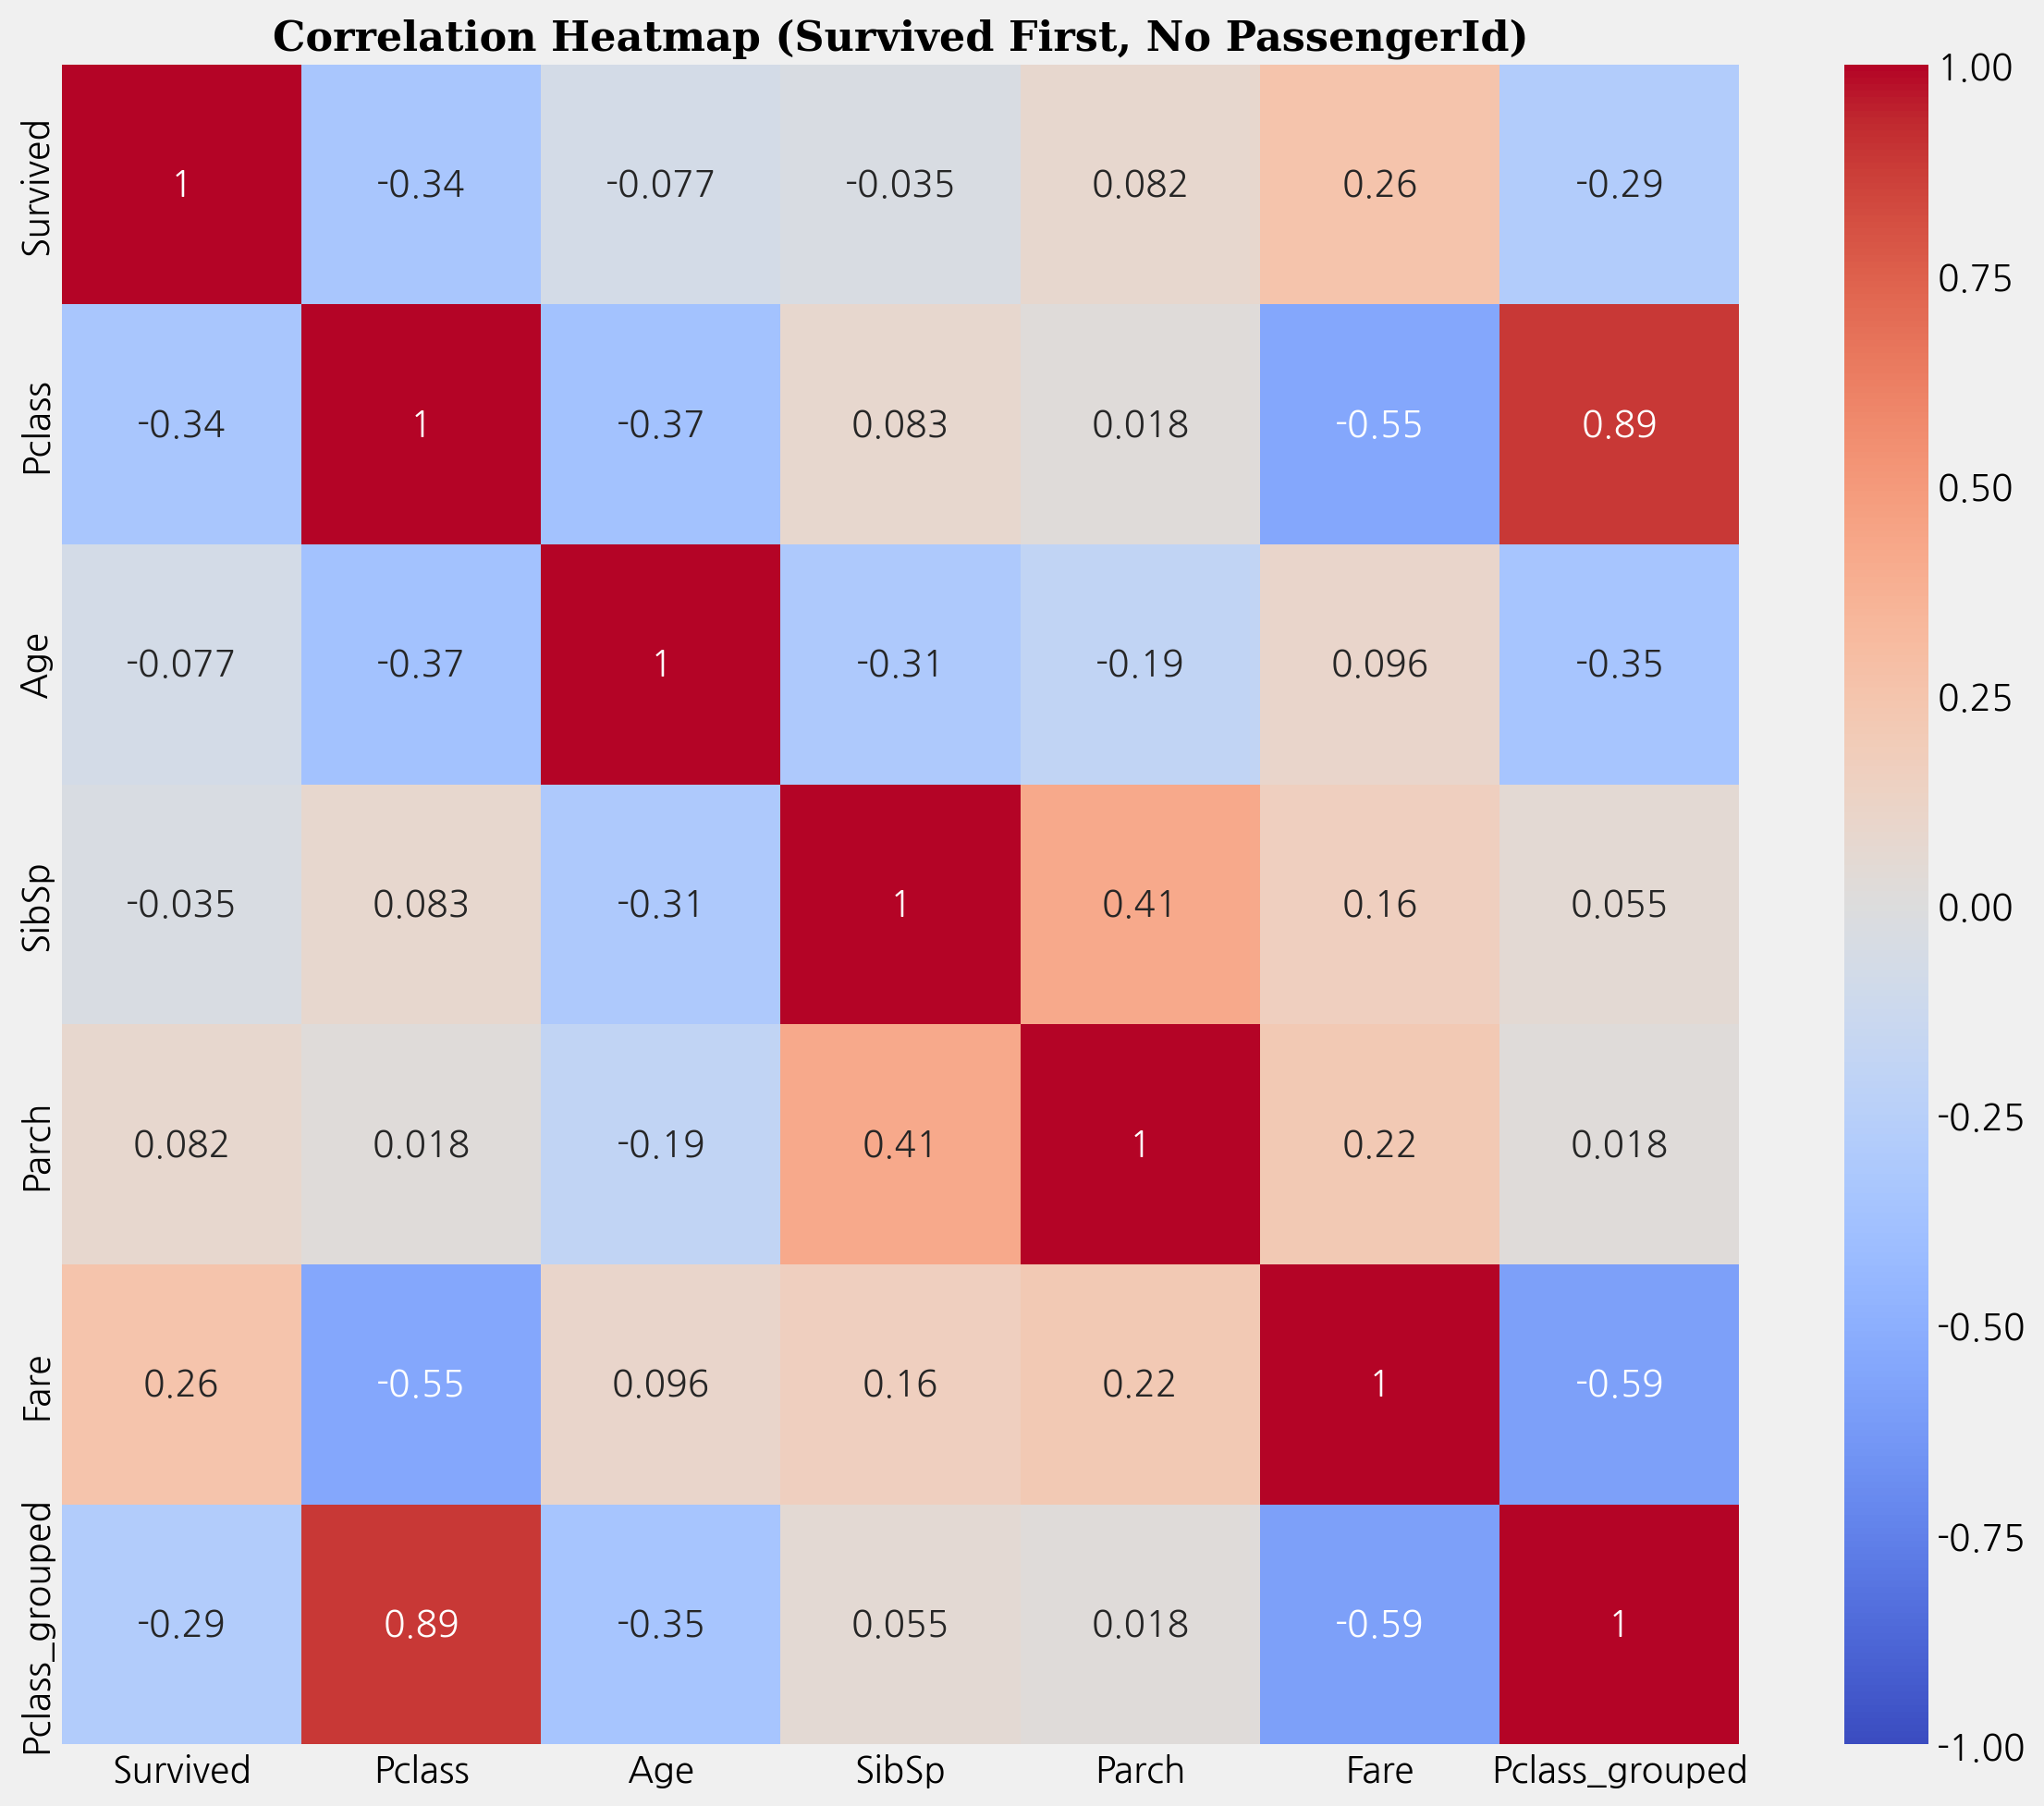

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 숫자형 컬럼만 선택 (PassengerId 제외)
numeric_train = ori_train.select_dtypes(include=[np.number]).drop(columns=['PassengerId'])

# 'Survived' 컬럼을 가장 앞쪽으로 이동
cols = ['Survived'] + [col for col in numeric_train.columns if col != 'Survived']
numeric_train = numeric_train[cols]

# Figure와 Axes 생성
fig, ax = plt.subplots(figsize=(12, 10))  # Figure 크기 설정

# Heatmap 시각화
sns.heatmap(numeric_train.corr(),
            annot=True,           # 상관계수 값을 셀에 표시
            vmin=-1, vmax=1,      # 색상 범위 설정
            center=0,             # 색상 맵의 중앙값 설정
            cmap='coolwarm',      # 색상 맵 설정
            ax=ax)                # Axes 객체 지정

# 제목 추가
ax.set_title('Correlation Heatmap (Survived First, No PassengerId)',
             fontsize=16, fontweight='bold', fontfamily='serif')

# 레이아웃 조정
plt.tight_layout()
plt.show()


## 컬럼 추가: Family

In [ ]:
# SibSp와 Parch를 합산하여 Family 컬럼 생성
ori_train['Family'] = ori_train['SibSp'] + ori_train['Parch']

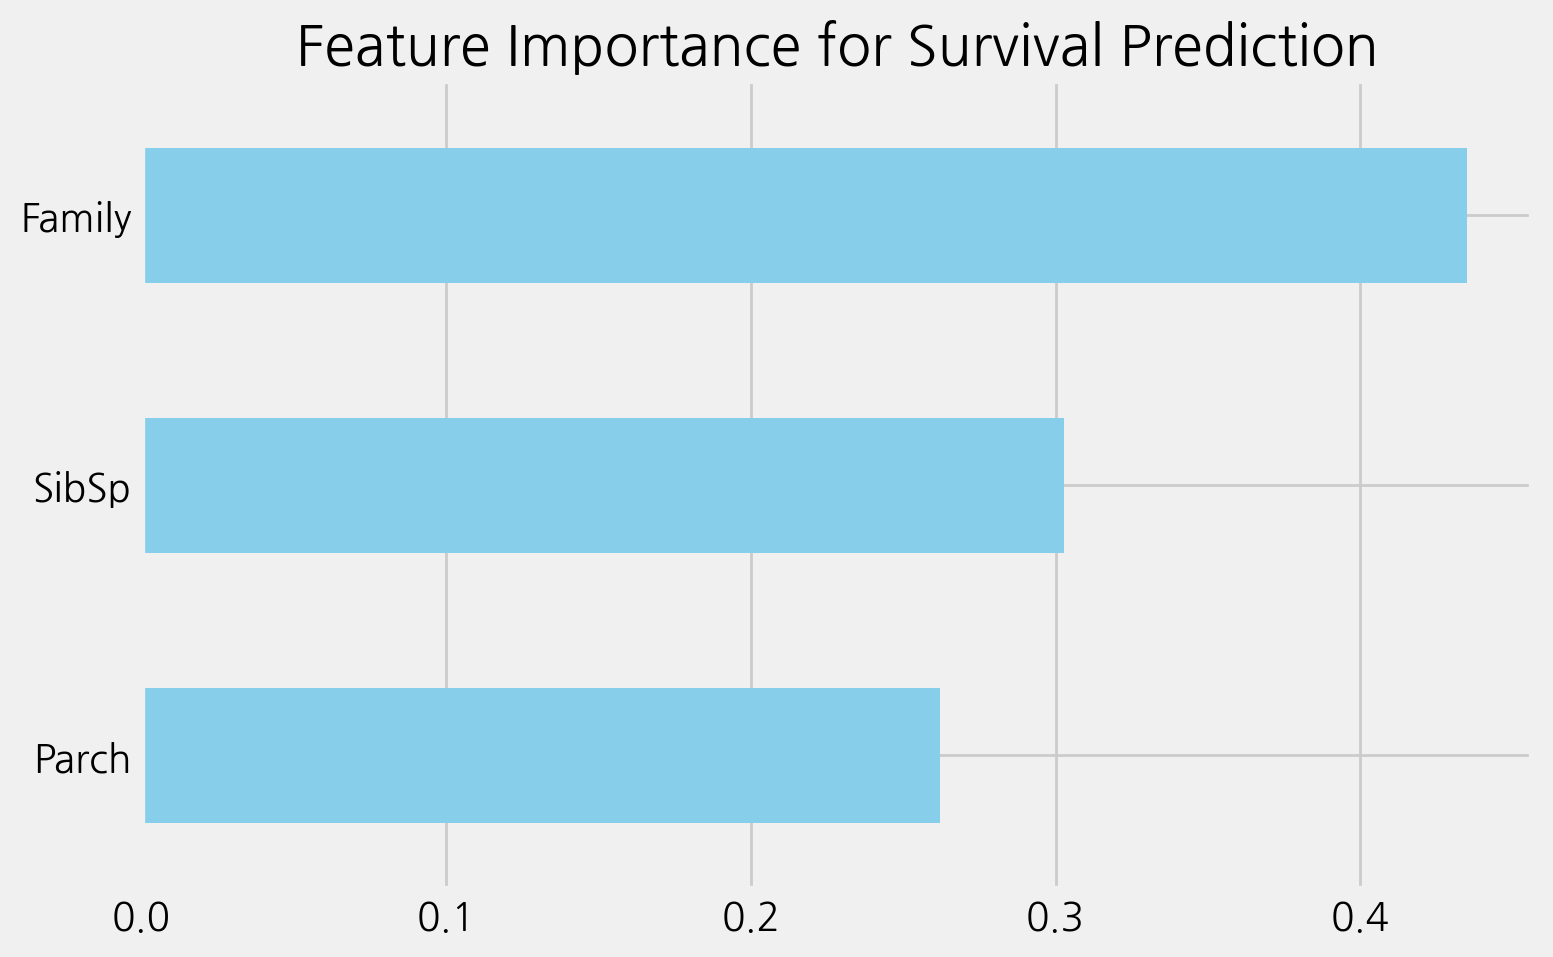

In [ ]:
# 랜덤 포레스트 모델을 사용해서 SibSp, Parch, Family 중 어떤 변수가 가장 중요한지를 확인
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# 모델 입력 변수 설정
X = ori_train[['SibSp', 'Parch', 'Family']]  # Family 포함
y = ori_train['Survived']

# 결측값 처리
X = X.fillna(X.median())

# 랜덤 포레스트 모델 훈련
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 특성 중요도 시각화
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8, 5), color='skyblue')

plt.title("Feature Importance for Survival Prediction")
plt.show()


In [ ]:
# SibSp, Parch를 그대로 사용할 때와, Family를 사용할 때 모델의 성능 차이를 비교
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

# 데이터 분할
X1 = ori_train[['SibSp', 'Parch']]  # 원래 변수
X2 = ori_train[['Family']]  # 새 변수
y = ori_train['Survived']

X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)
X2_train, X2_test, _, _ = train_test_split(X2, y, test_size=0.2, random_state=42)

# 모델 학습 및 평가 (Logistic Regression 사용)
model1 = LogisticRegression()
model1.fit(X1_train, y_train)
pred1 = model1.predict(X1_test)

model2 = LogisticRegression()
model2.fit(X2_train, y_train)
pred2 = model2.predict(X2_test)

# 정확도 비교
print(f"모델 (SibSp + Parch) 정확도: {accuracy_score(y_test, pred1):.4f}")
print(f"모델 (Family 단독) 정확도: {accuracy_score(y_test, pred2):.4f}")


모델 (SibSp + Parch) 정확도: 0.5922
모델 (Family 단독) 정확도: 0.5866


## Cabin 결측치 처리하기: 컬럼 제거(Pclass와 유사)

In [ ]:
# Cabin은 방 호수이다. Pclass와 연관성이 깊다면, 사용하지 않아도 괜찮다.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cabin 컬럼에서 Deck(층) 정보 추출 (첫 번째 문자)
ori_train['Deck'] = ori_train['Cabin'].astype(str).str[0]  # NaN -> 'n'으로 변환됨

# 결측값(Nan) 처리 - 'U'로 채우기 (Unknown)
ori_train['Deck'] = ori_train['Deck'].replace('n', 'U')  # 'n'을 'U'(Unknown)으로 변경

# Deck별 Pclass 개수 확인
deck_pclass_counts = ori_train.groupby(['Deck', 'Pclass']).size().unstack().fillna(0)

# 출력
print(deck_pclass_counts)

Pclass     1      2      3
Deck                      
A       15.0    0.0    0.0
B       47.0    0.0    0.0
C       59.0    0.0    0.0
D       29.0    4.0    0.0
E       25.0    4.0    3.0
F        0.0    8.0    5.0
G        0.0    0.0    4.0
T        1.0    0.0    0.0
U       40.0  168.0  479.0


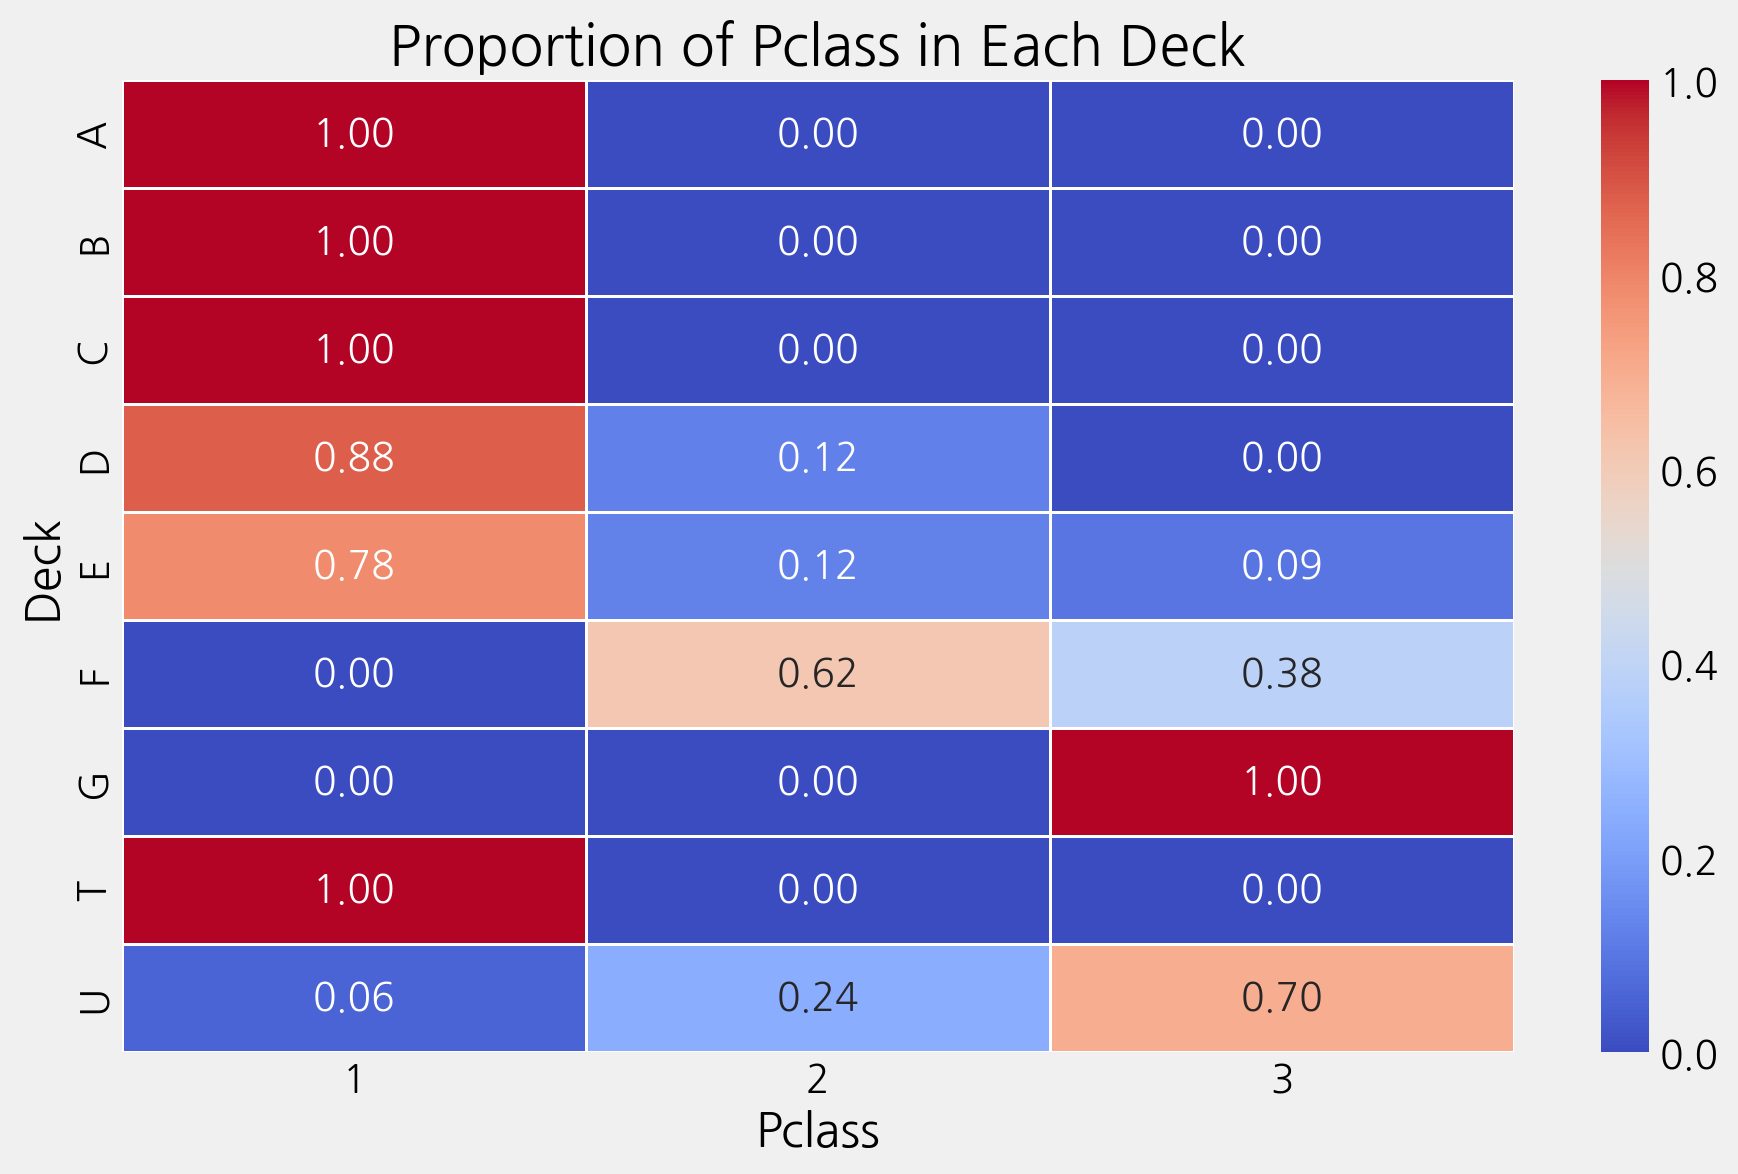

In [ ]:
# Pclass 기준으로 Deck 비율 계산
deck_pclass_ratio = deck_pclass_counts.div(deck_pclass_counts.sum(axis=1), axis=0)

# 시각화
plt.figure(figsize=(10, 6))
sns.heatmap(deck_pclass_ratio, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.xlabel("Pclass")
plt.ylabel("Deck")
plt.title("Proportion of Pclass in Each Deck")
plt.show()


In [ ]:
import pandas as pd

# Deck 그룹화 (A~E는 High, F는 Mid, G는 Low, 나머지는 Unknown)
ori_train['Deck_grouped'] = ori_train['Deck'].apply(lambda x: 'High' if x in ['A', 'B', 'C', 'D', 'E']
                                                   else ('Mid' if x in ['F'] else ('Low' if x in ['G'] else 'Unknown')))

# 결과 확인
print(ori_train[['Deck', 'Deck_grouped']].head(10))

  Deck Deck_grouped
0    U      Unknown
1    C         High
2    U      Unknown
3    C         High
4    U      Unknown
5    U      Unknown
6    E         High
7    U      Unknown
8    U      Unknown
9    U      Unknown


📌 Deck 그룹화 방식

- A, B, C, D, E → High (상류층 객실)
- F → Mid (중간층 객실)
- G → Low (하층 객실)

In [ ]:
# Deck_grouped를 One-Hot Encoding 변환 (drop_first=False 유지)
deck_dummies = pd.get_dummies(ori_train['Deck_grouped'], drop_first=False)

# Pclass와 결합
pclass_deck_corr = pd.concat([ori_train[['Pclass']], deck_dummies], axis=1)

# 상관계수 계산
corr_matrix = pclass_deck_corr.corr()

# 결과 출력
print(corr_matrix)


           Pclass      High       Low       Mid   Unknown
Pclass   1.000000 -0.758153  0.055561  0.011063  0.722607
High    -0.758153  1.000000 -0.034493 -0.062501 -0.945601
Low      0.055561 -0.034493  1.000000 -0.008171 -0.123627
Mid      0.011063 -0.062501 -0.008171  1.000000 -0.224012
Unknown  0.722607 -0.945601 -0.123627 -0.224012  1.000000


<Figure size 800x500 with 0 Axes>

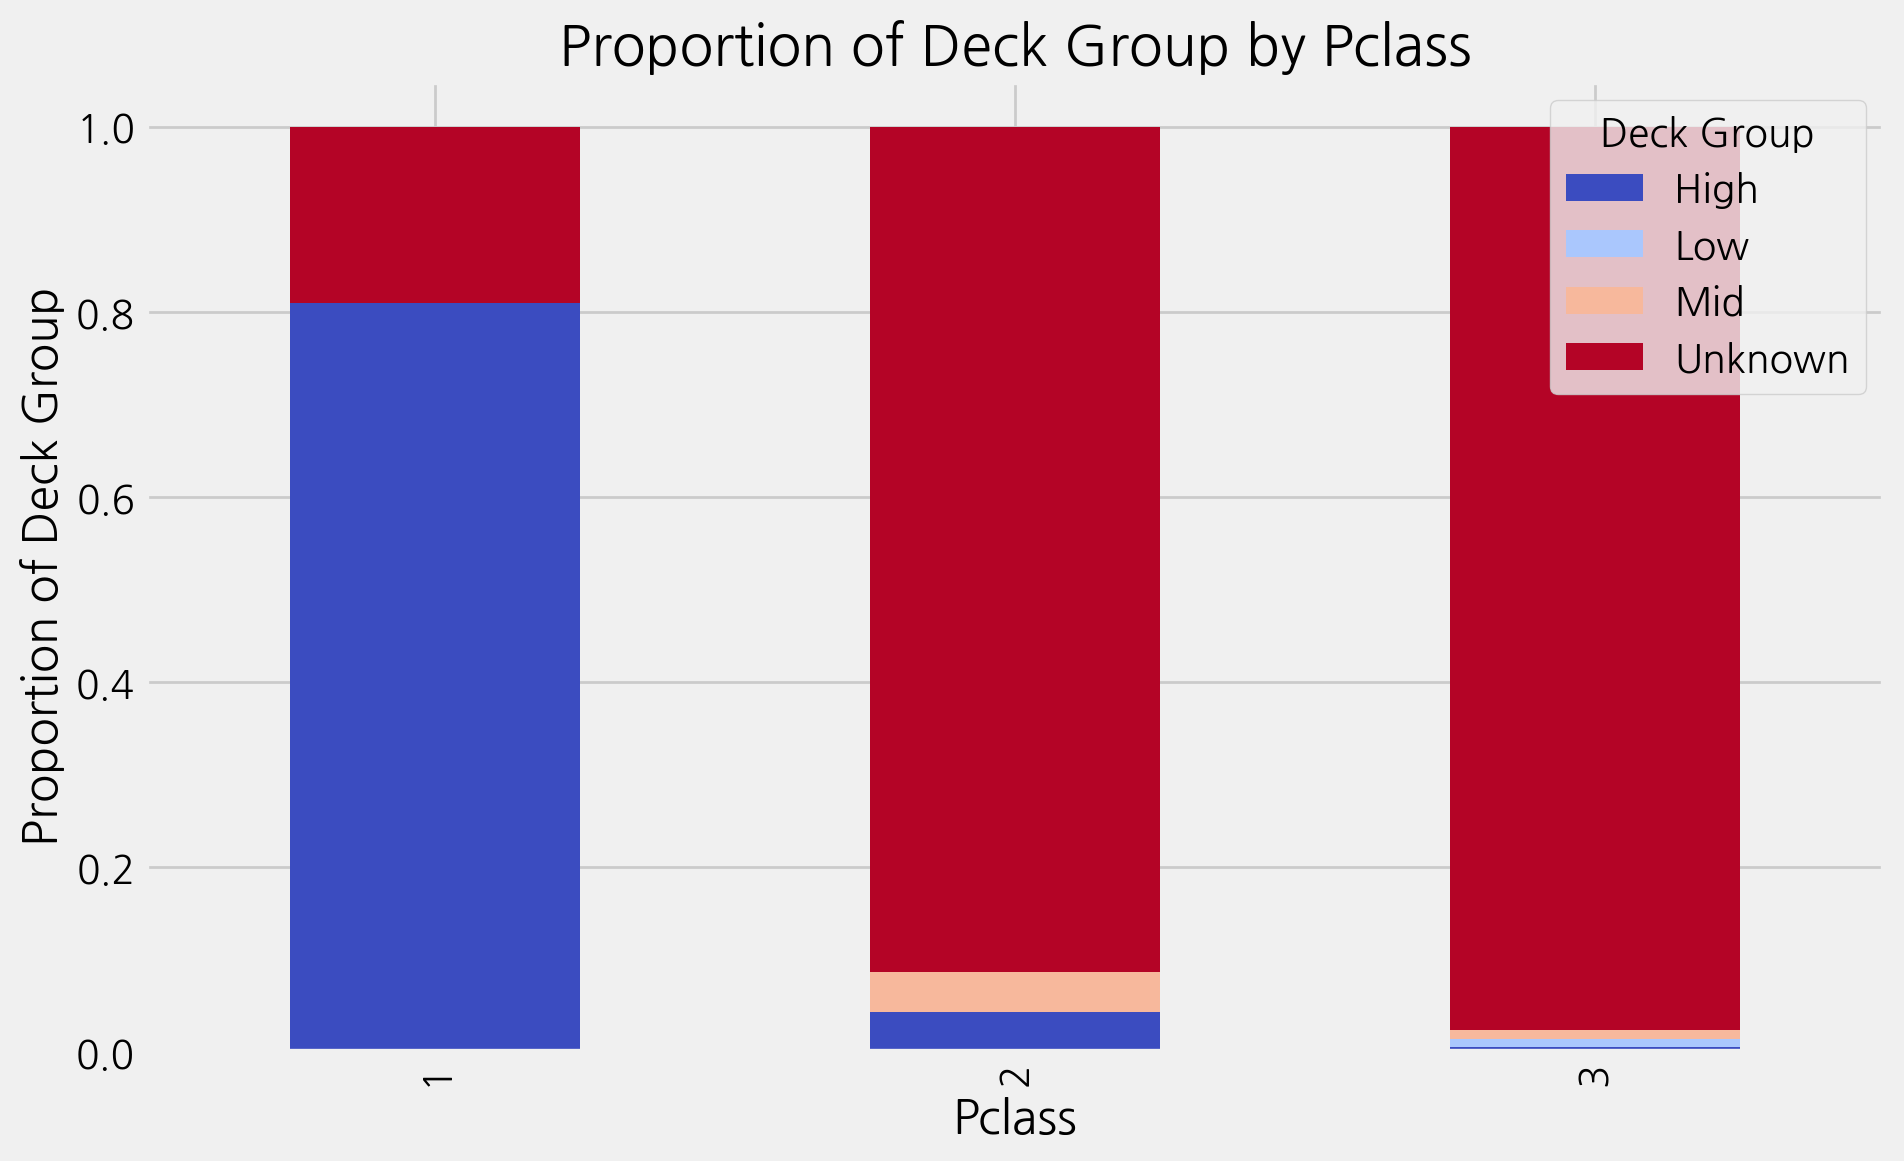

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pclass별 Deck_grouped 비율 계산
deck_pclass_ratio = ori_train.groupby('Pclass')['Deck_grouped'].value_counts(normalize=True).unstack()

# 시각화
plt.figure(figsize=(8, 5))
deck_pclass_ratio.plot(kind='bar', stacked=True, colormap="coolwarm", figsize=(10, 6))
plt.xlabel("Pclass")
plt.ylabel("Proportion of Deck Group")
plt.title("Proportion of Deck Group by Pclass")
plt.legend(title="Deck Group")
plt.show()


In [ ]:
from scipy.stats import chi2_contingency

# Pclass와 Deck_grouped의 교차표 생성
contingency_table = pd.crosstab(ori_train['Pclass'], ori_train['Deck_grouped'])

# 카이제곱 검정 수행
chi2, p, dof, expected = chi2_contingency(contingency_table)

# 결과 출력
print(f"카이제곱 통계량: {chi2:.2f}")
print(f"p-value: {p:.4f}")

# p-value < 0.05면 유의미한 관계가 있다고 해석
if p < 0.05:
    print("✅ Deck_grouped와 Pclass는 유의미한 관계를 가짐!")
else:
    print("❌ Deck_grouped와 Pclass는 독립적일 가능성이 높음.")


카이제곱 통계량: 638.43
p-value: 0.0000
✅ Deck_grouped와 Pclass는 유의미한 관계를 가짐!


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Pclass만 사용한 데이터
X_pclass = ori_train[['Pclass']]
y = ori_train['Survived']

# Pclass + Deck 함께 사용한 데이터
X_pclass_deck = pd.get_dummies(ori_train[['Pclass', 'Deck_grouped']], drop_first=False)

# 랜덤 포레스트 모델 훈련
model_pclass = RandomForestClassifier(n_estimators=100, random_state=42)
model_pclass.fit(X_pclass, y)

model_pclass_deck = RandomForestClassifier(n_estimators=100, random_state=42)
model_pclass_deck.fit(X_pclass_deck, y)

# 특성 중요도 비교
importance_pclass = pd.Series(model_pclass.feature_importances_, index=X_pclass.columns)
importance_pclass_deck = pd.Series(model_pclass_deck.feature_importances_, index=X_pclass_deck.columns)

# 결과 출력
print("Feature Importance (Pclass만 사용):")
print(importance_pclass.sort_values(ascending=False))

print("\nFeature Importance (Pclass + Deck 사용):")
print(importance_pclass_deck.sort_values(ascending=False))


Feature Importance (Pclass만 사용):
Pclass    1.0
dtype: float64

Feature Importance (Pclass + Deck 사용):
Pclass                  0.469690
Deck_grouped_Unknown    0.299412
Deck_grouped_High       0.200233
Deck_grouped_Mid        0.020621
Deck_grouped_Low        0.010044
dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# 데이터 분할
X_train_pclass, X_test_pclass, y_train, y_test = train_test_split(X_pclass, y, test_size=0.2, random_state=42)
X_train_pclass_deck, X_test_pclass_deck, _, _ = train_test_split(X_pclass_deck, y, test_size=0.2, random_state=42)

# 모델 학습 (Pclass만 사용)
model_pclass = RandomForestClassifier(n_estimators=100, random_state=42)
model_pclass.fit(X_train_pclass, y_train)
pred_pclass = model_pclass.predict(X_test_pclass)

# 모델 학습 (Pclass + Deck 사용)
model_pclass_deck = RandomForestClassifier(n_estimators=100, random_state=42)
model_pclass_deck.fit(X_train_pclass_deck, y_train)
pred_pclass_deck = model_pclass_deck.predict(X_test_pclass_deck)

# 정확도 비교
accuracy_pclass = accuracy_score(y_test, pred_pclass)
accuracy_pclass_deck = accuracy_score(y_test, pred_pclass_deck)

print(f"모델 성능 (Pclass만 사용): {accuracy_pclass:.4f}")
print(f"모델 성능 (Pclass + Deck 사용): {accuracy_pclass_deck:.4f}")


모델 성능 (Pclass만 사용): 0.7039
모델 성능 (Pclass + Deck 사용): 0.6983


Pclass만 사용하기

## Age 결측치 처리하기: Pclass별 Age의 평균/중앙값으로 대체

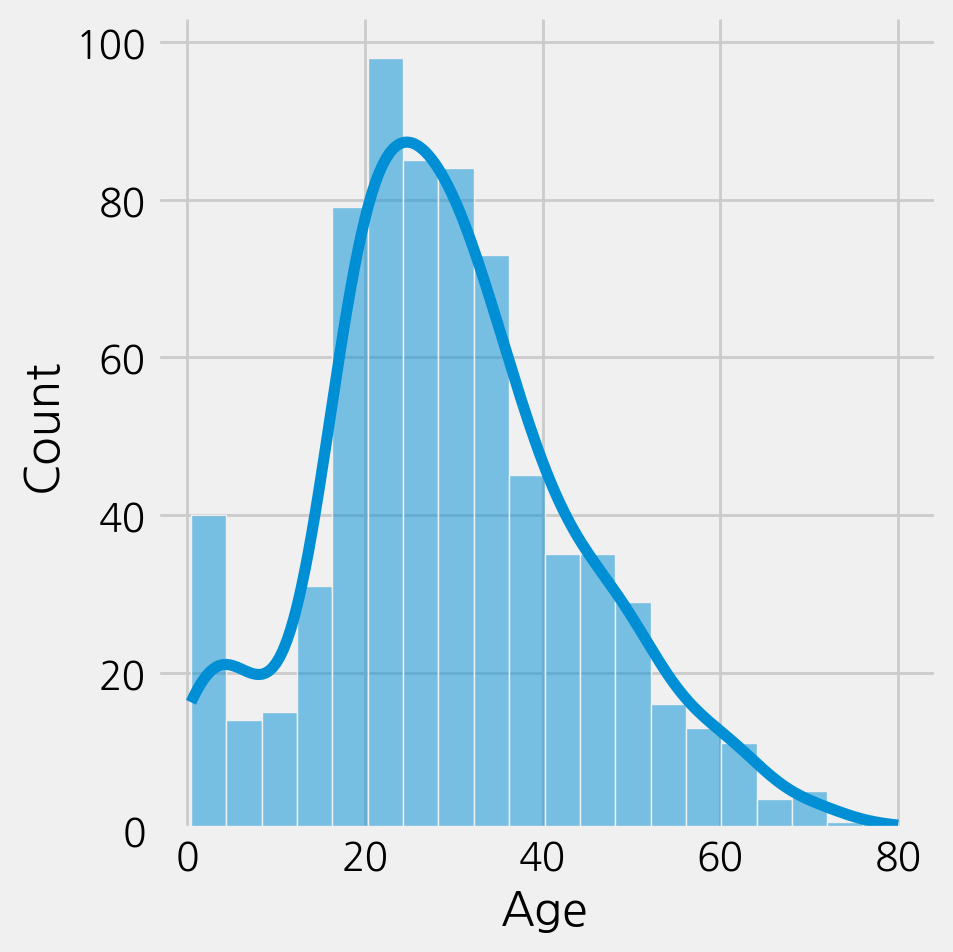

In [ ]:
# 분포 확인
sns.displot(ori_train['Age'], kde=True)
plt.show()

In [ ]:
# 상관관계 계산 (Pearson Correlation)
correlation = ori_train[['Pclass', 'Age']].corr().loc['Pclass', 'Age']  # 'Pclass', 'Age'로 변경
print(f"Pclass와 Age의 상관계수: {correlation}")

Pclass와 Age의 상관계수: -0.36922601531551735


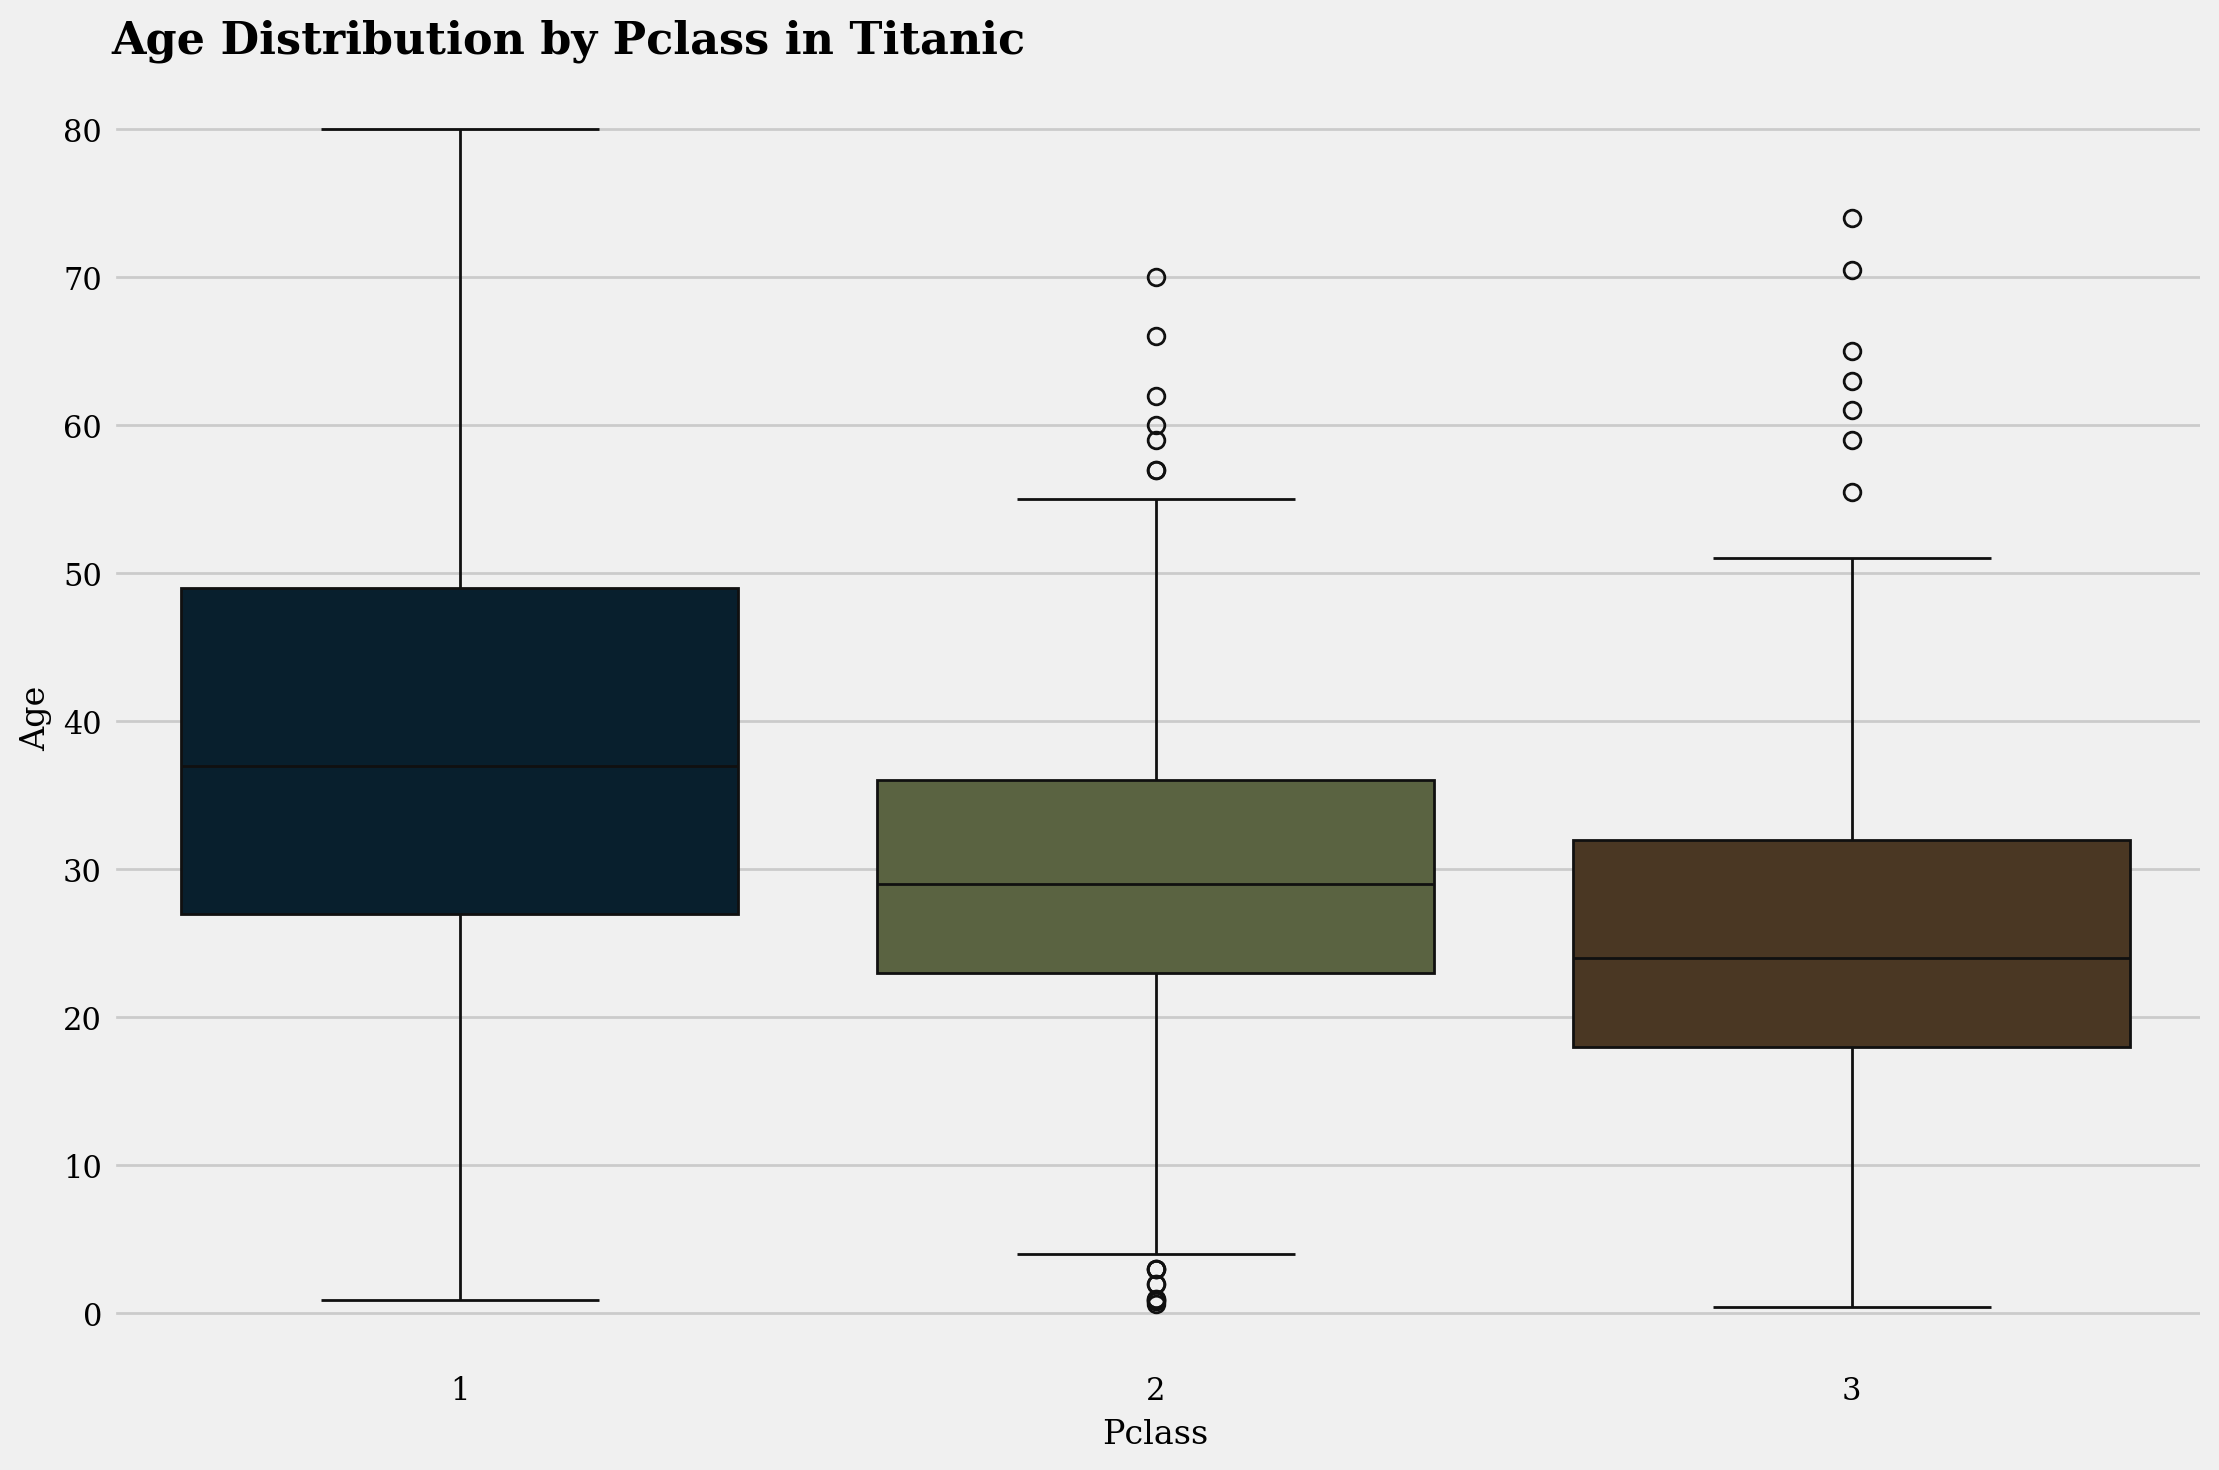

In [ ]:
plt.figure(figsize=(12, 8))

# 박스플롯 그리기
sns.boxplot(x='Pclass', y='Age', data=ori_train, palette=["#022133", "#5c693b", "#51371c"])

# 제목과 스타일 조정
plt.title('Age Distribution by Pclass in Titanic', fontweight='bold', fontsize=16, fontfamily='serif', loc='left')
plt.xlabel('Pclass', fontfamily='serif', fontsize=12)
plt.ylabel('Age', fontfamily='serif', fontsize=12)

# 테두리 없애기
sns.despine()

# 전체 폰트 스타일 통일
plt.xticks(fontfamily='serif', fontsize=11)
plt.yticks(fontfamily='serif', fontsize=11)

plt.show()

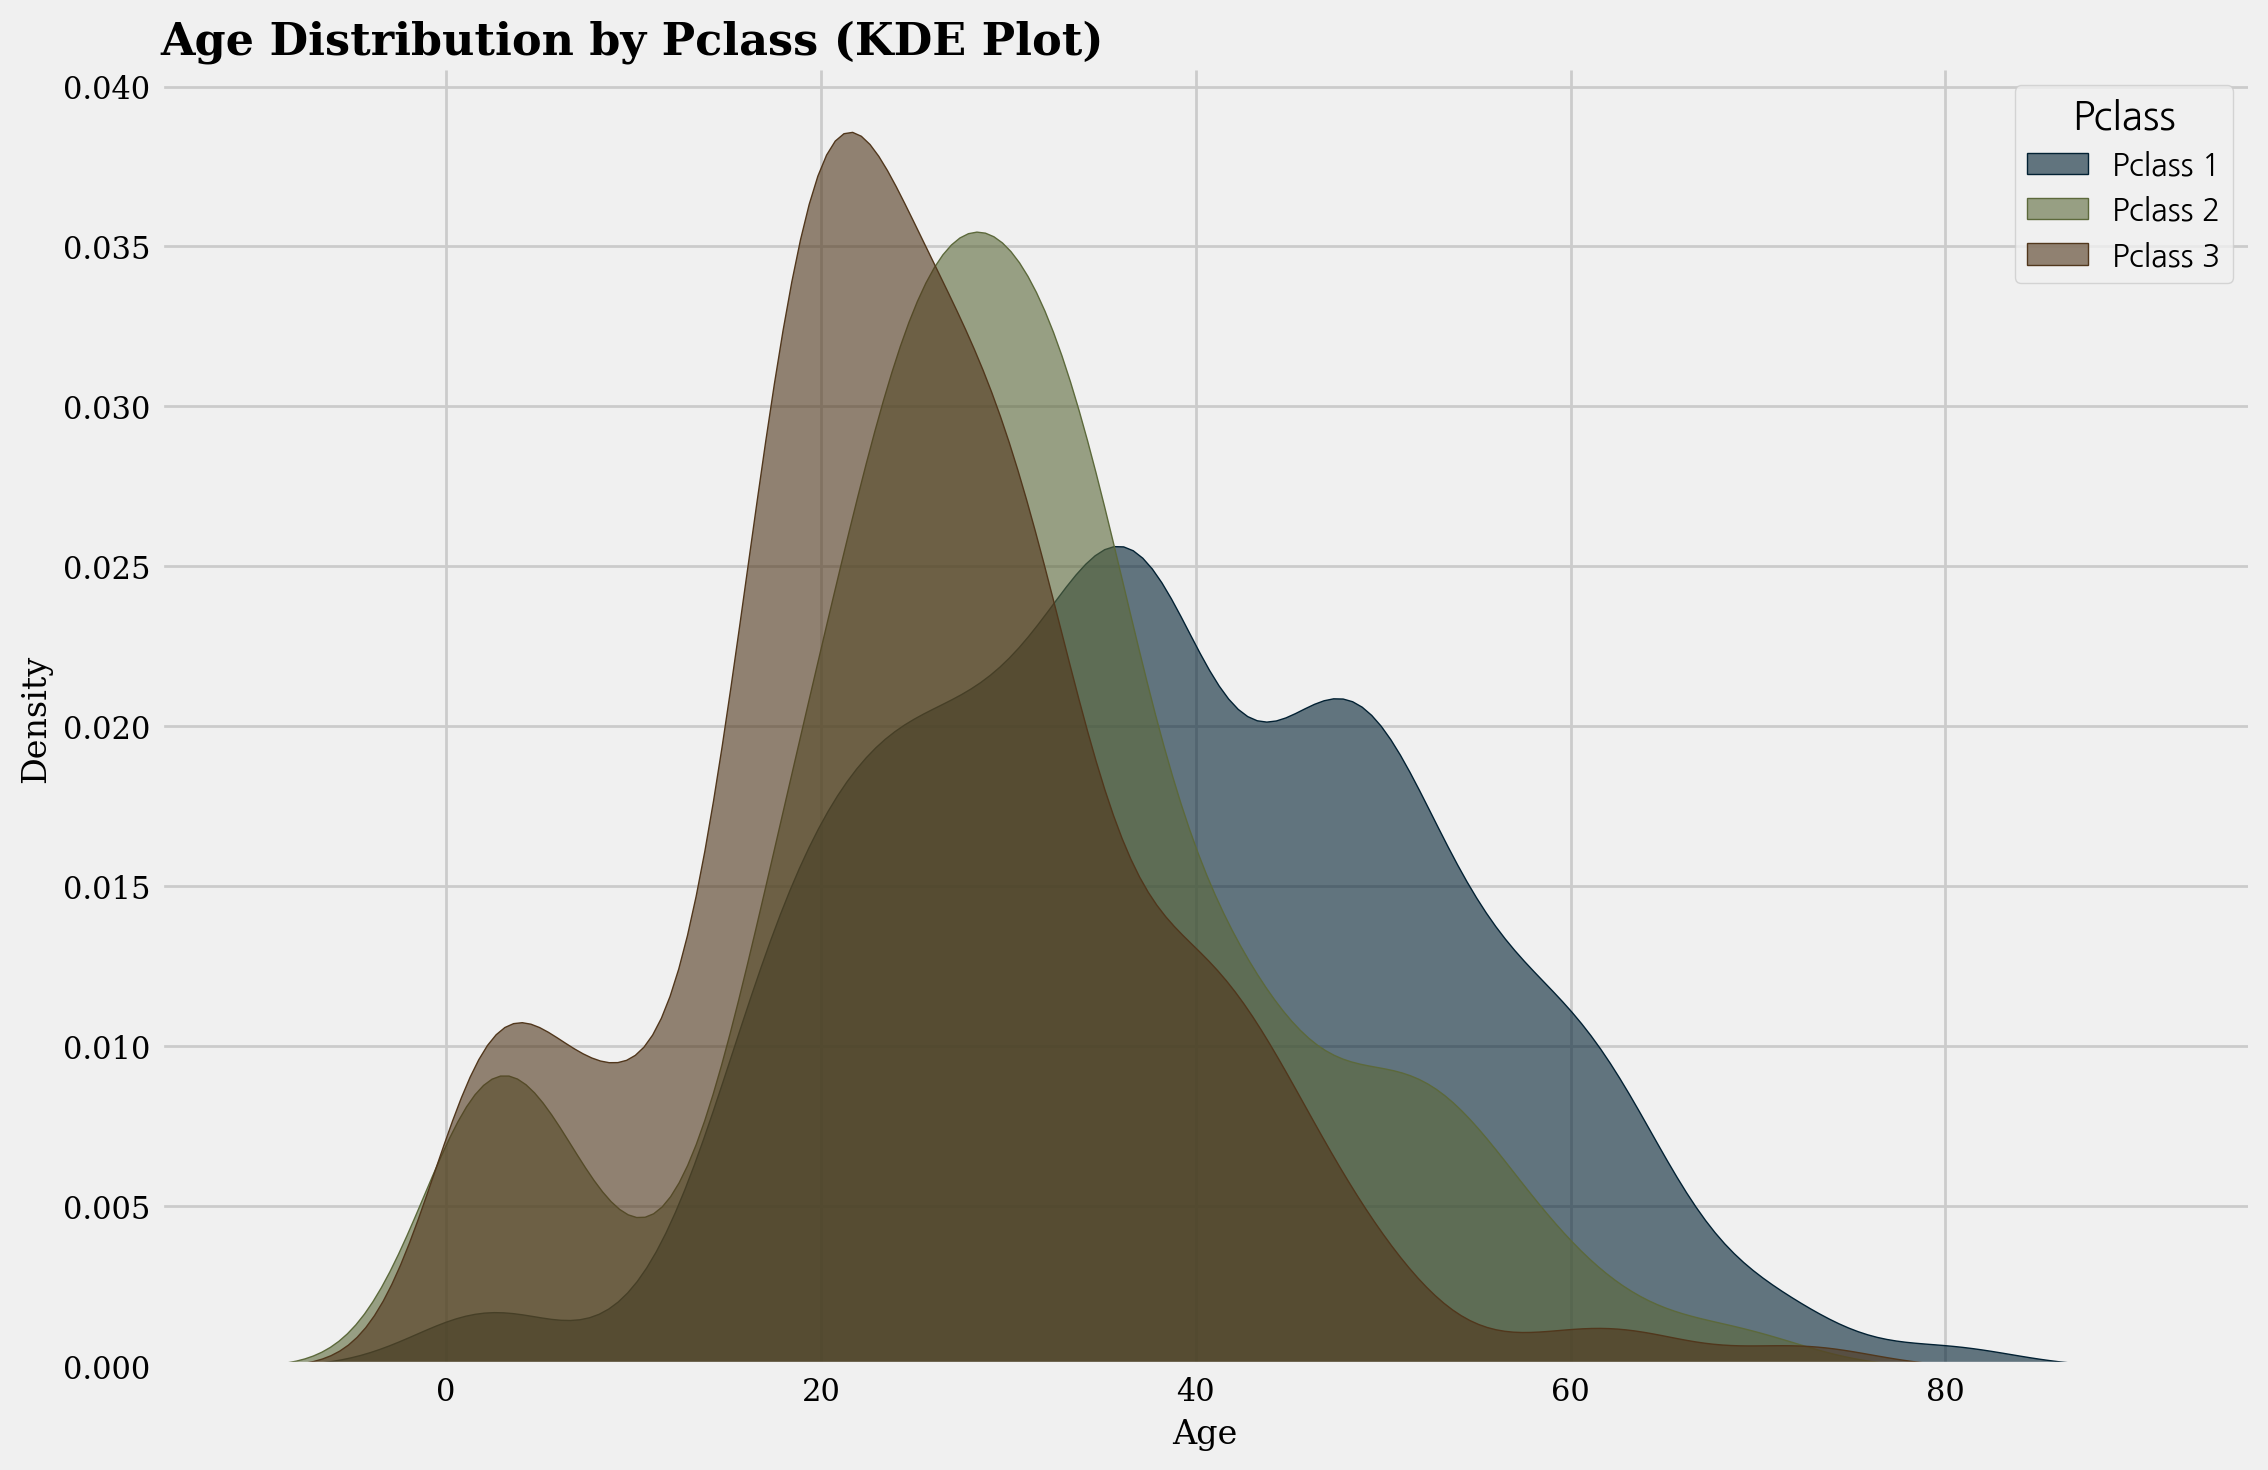

In [ ]:
plt.figure(figsize=(12, 8))

# Pclass별 Age 분포 KDE Plot
colors = ["#022133", "#5c693b", "#51371c"]

for cls, color in zip(sorted(ori_train['Pclass'].unique()), colors):
    sns.kdeplot(
        data=ori_train[ori_train['Pclass'] == cls],
        x='Age',
        fill=True,
        alpha=0.6,
        bw_method=0.25,
        color=color,
        label=f'Pclass {cls}'
    )

# 그래프 제목 및 스타일
plt.title('Age Distribution by Pclass (KDE Plot)', fontweight='bold', fontsize=16, fontfamily='serif', loc='left')
plt.xlabel('Age', fontfamily='serif', fontsize=12)
plt.ylabel('Density', fontfamily='serif', fontsize=12)

# 범례, 테두리 제거
plt.legend(title='Pclass', fontsize=11)
sns.despine()

plt.xticks(fontfamily='serif', fontsize=11)
plt.yticks(fontfamily='serif', fontsize=11)

plt.show()

In [ ]:
ori_train.groupby('Pclass')['Age'].median()

,Age
Pclass,
1,37.0
2,29.0
3,24.0


In [ ]:
ori_train.groupby('Pclass')['Age'].mean()

,Age
Pclass,
1,38.233441
2,29.877630
3,25.140620


In [ ]:
# Pclass는 범주형, Age는 연속형이니까 ANOVA로 Pclass별 Age 평균 차이가 통계적으로 유의한지 검정
# 귀무가설: Pclass별 Age 평균은 같다
from scipy import stats

# Pclass별로 Age 데이터 추출 (결측치는 제거)
age_p1 = ori_train[ori_train['Pclass'] == 1]['Age'].dropna()
age_p2 = ori_train[ori_train['Pclass'] == 2]['Age'].dropna()
age_p3 = ori_train[ori_train['Pclass'] == 3]['Age'].dropna()

# ANOVA 수행
f_stat, p_val = stats.f_oneway(age_p1, age_p2, age_p3)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_val:.4f}")


F-statistic: 57.4435, p-value: 0.0000


p-value < 0.05이므로 → 귀무가설 기각: Pclass별 Age 평균에는 유의미한 차이 있음

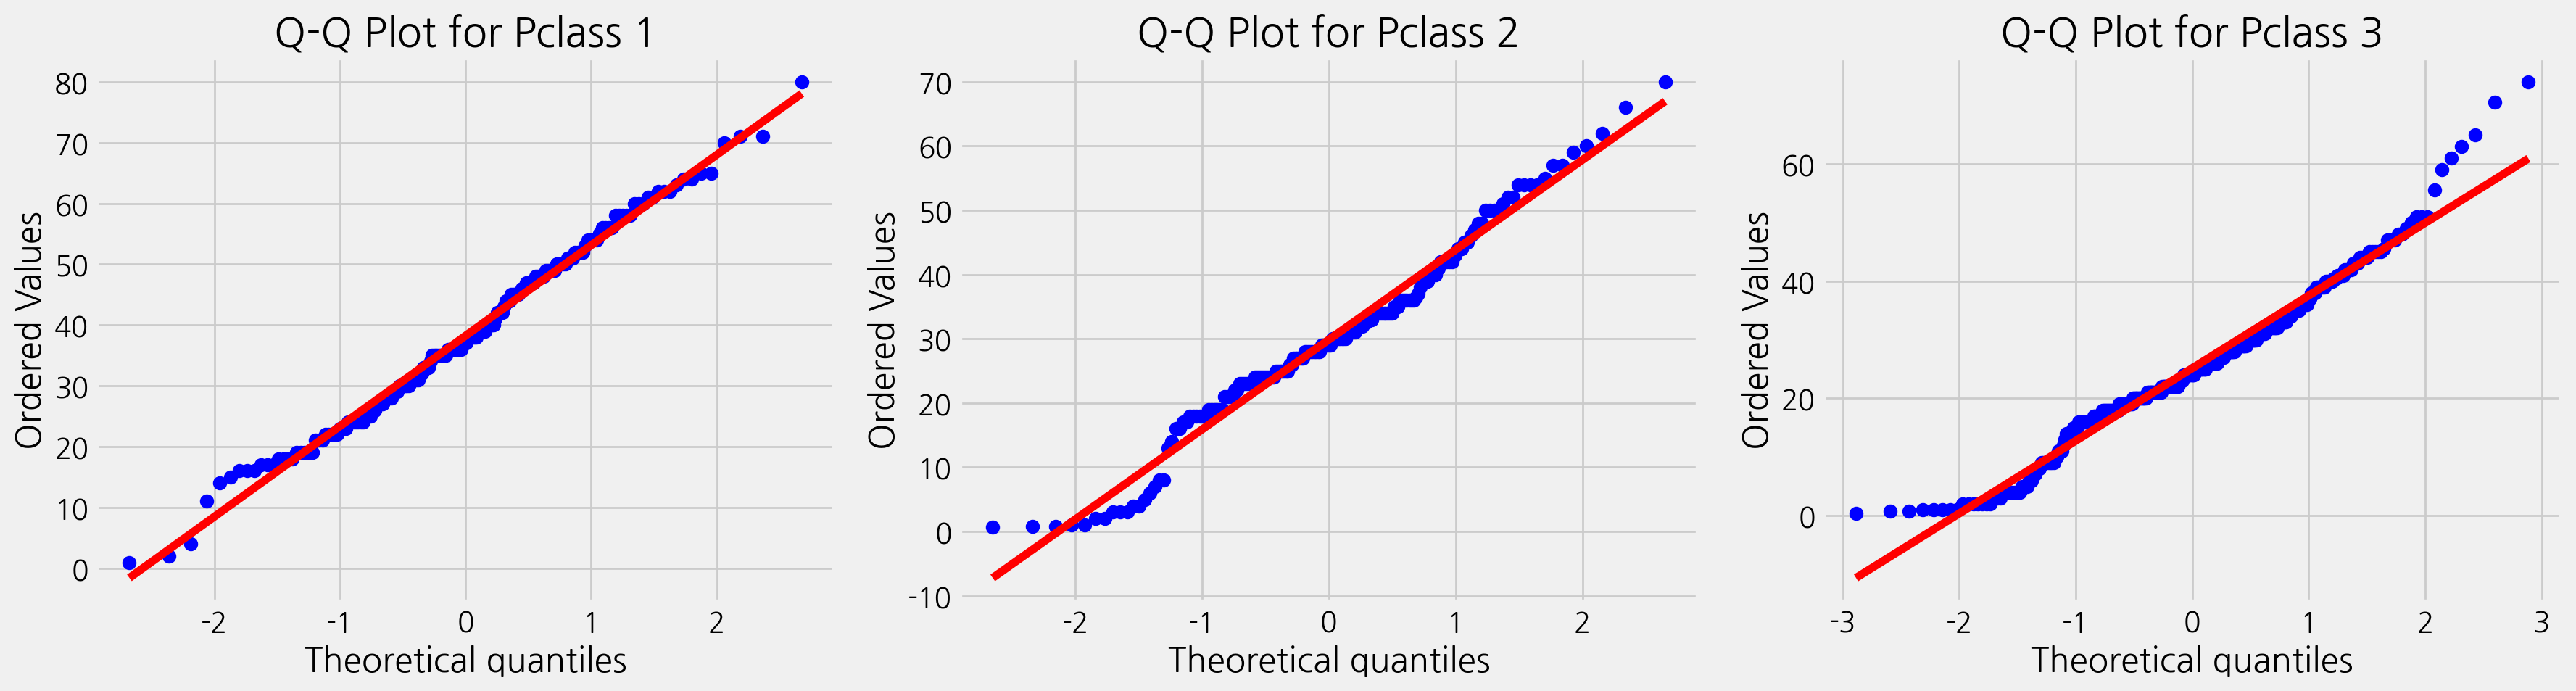

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

pclasses = sorted(ori_train['Pclass'].unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, cls in enumerate(pclasses):
    age_data = ori_train[ori_train['Pclass'] == cls]['Age'].dropna()
    stats.probplot(age_data, dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q Plot for Pclass {cls}')

plt.tight_layout()
plt.show()


In [ ]:
#  Shapiro-Wilk Test
for cls in pclasses:
    age_data = ori_train[ori_train['Pclass'] == cls]['Age'].dropna()
    stat, p = stats.shapiro(age_data)
    print(f'Pclass {cls} - W Statistic={stat:.4f}, p-value={p:.4f}')


Pclass 1 - W Statistic=0.9917, p-value=0.3643
Pclass 2 - W Statistic=0.9770, p-value=0.0056
Pclass 3 - W Statistic=0.9734, p-value=0.0000


- Pclass 1 → 평균으로 결측치 대체
Pclass 2, Pclass 3 → 중위값으로 결측치 대체

In [ ]:
# Pclass 1 -> 평균으로 채우기
ori_train.loc[(ori_train['Pclass'] == 1) & (ori_train['Age'].isna()), 'Age'] = \
    ori_train.loc[ori_train['Pclass'] == 1, 'Age'].mean()

# Pclass 2, 3 -> 중위값으로 채우기
for cls in [2, 3]:
    ori_train.loc[(ori_train['Pclass'] == cls) & (ori_train['Age'].isna()), 'Age'] = \
        ori_train.loc[ori_train['Pclass'] == cls, 'Age'].median()


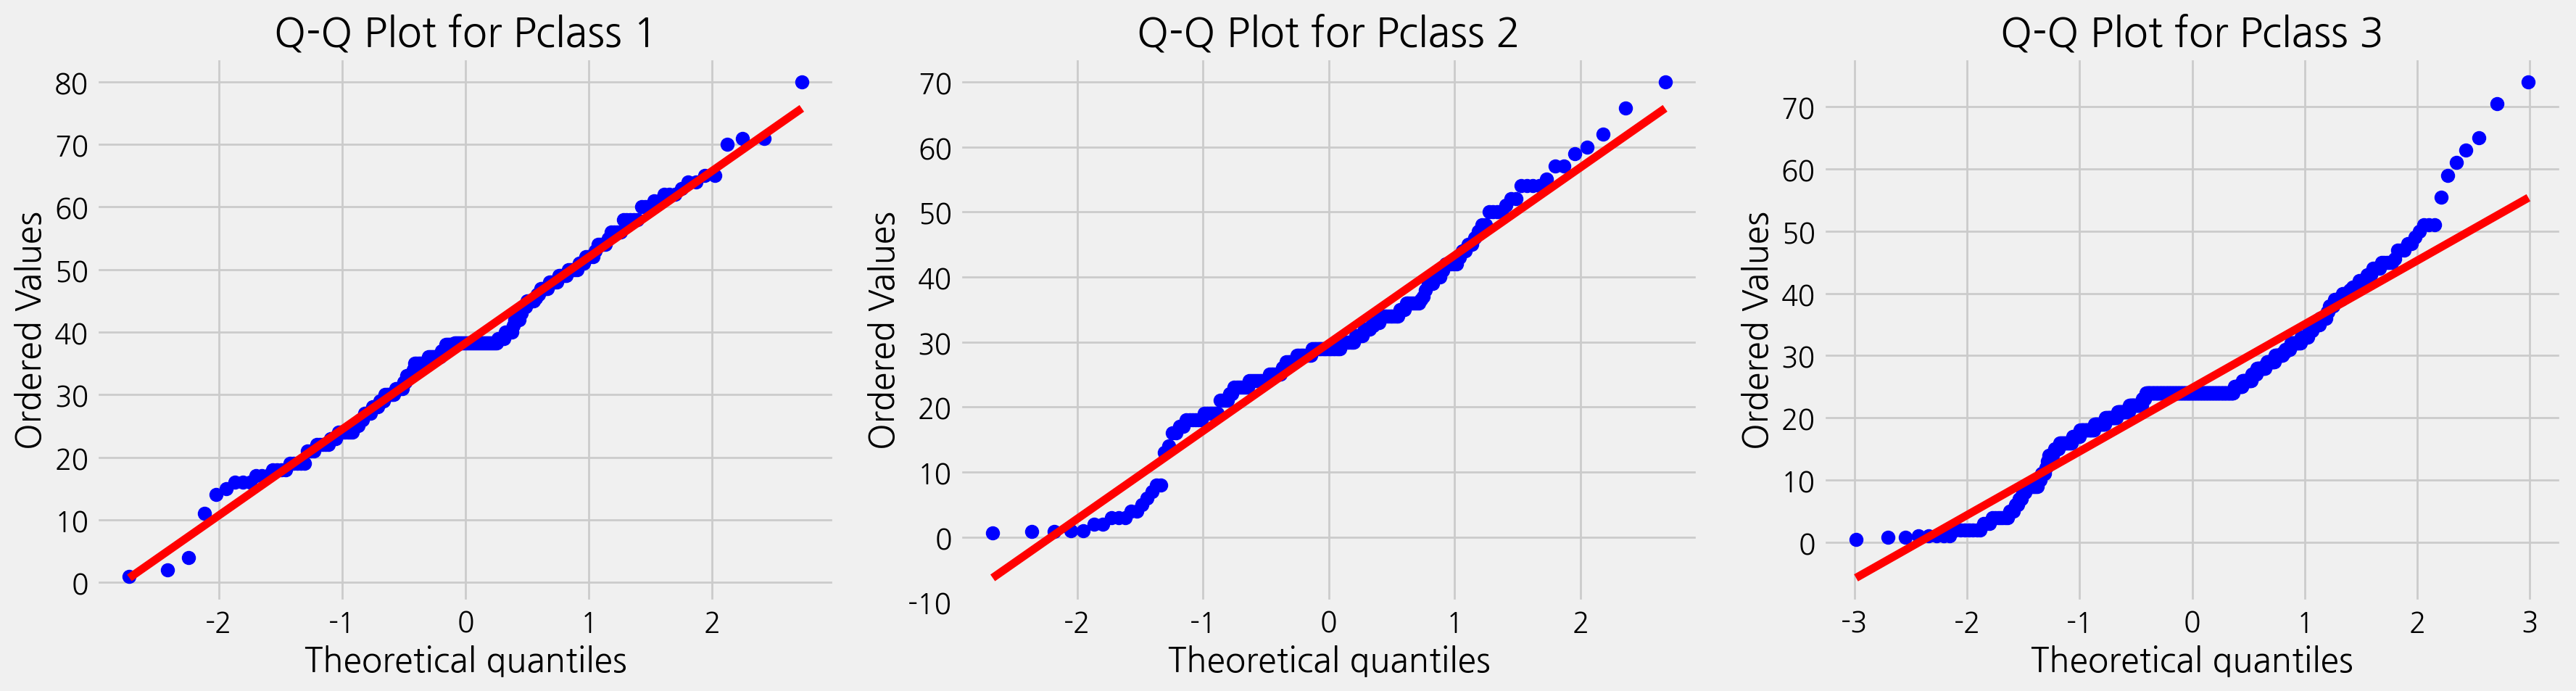

Pclass 1 - W Statistic=0.9889, p-value=0.0917
Pclass 2 - W Statistic=0.9707, p-value=0.0007
Pclass 3 - W Statistic=0.9191, p-value=0.0000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

pclasses = sorted(ori_train['Pclass'].unique())

# ✅ Q-Q Plot으로 시각적 정규성 확인
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, cls in enumerate(pclasses):
    age_data = ori_train[ori_train['Pclass'] == cls]['Age'].dropna()
    stats.probplot(age_data, dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q Plot for Pclass {cls}')
plt.tight_layout()
plt.show()

# ✅ Shapiro-Wilk Test로 정규성 검정
for cls in pclasses:
    age_data = ori_train[ori_train['Pclass'] == cls]['Age'].dropna()
    stat, p = stats.shapiro(age_data)
    print(f'Pclass {cls} - W Statistic={stat:.4f}, p-value={p:.4f}')


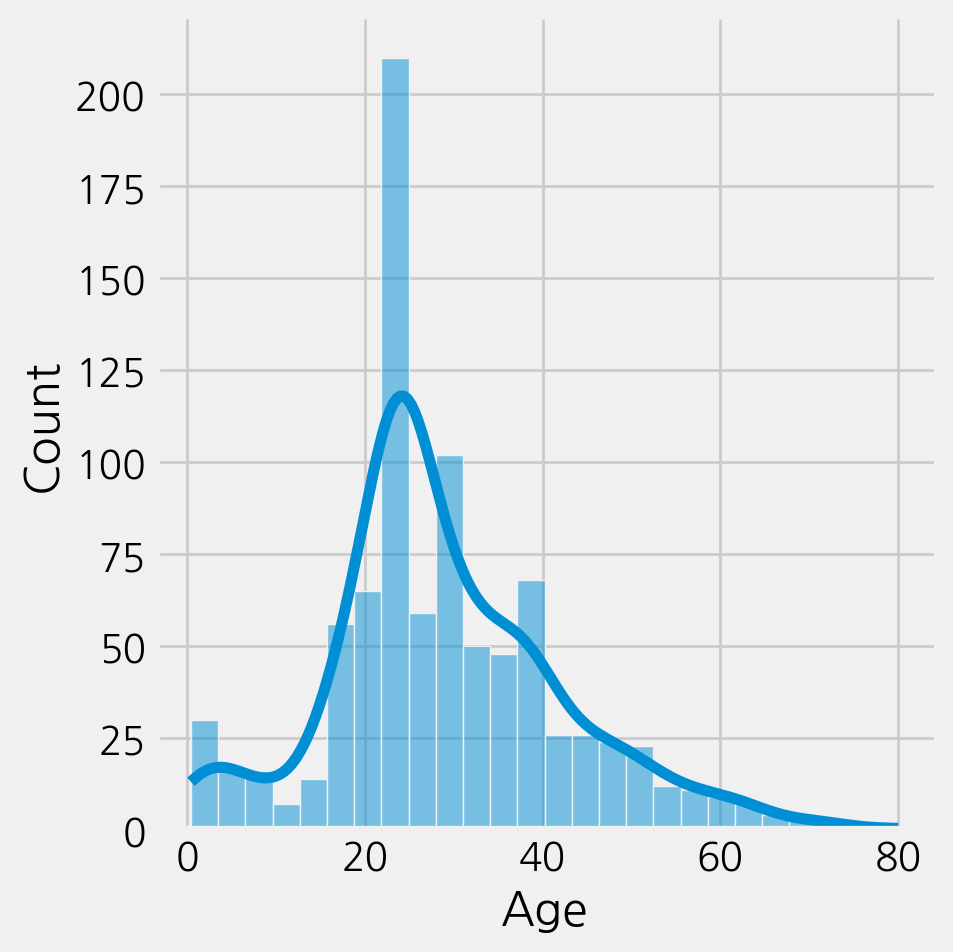

In [ ]:
# 분포 확인
sns.displot(ori_train['Age'], kde=True)
plt.show()

## Embarked 결측치: 최빈값 대체

In [ ]:
# Embarked 최빈값 구하기
embarked_mode = ori_train['Embarked'].mode()[0]

# 결측치 최빈값으로 대체
ori_train['Embarked'] = ori_train['Embarked'].fillna(embarked_mode)


## 이상치 판단: Age&Fare 컬럼

### Z-Score

In [ ]:
from scipy import stats
import numpy as np

# Age Z-score 계산 (결측치 제외)
z_scores = stats.zscore(ori_train['Age'].dropna())
abs_z_scores = np.abs(z_scores)
age_threshold = 3

# Age 이상치 인덱스
age_outlier_idx = ori_train['Age'].dropna().index[abs_z_scores > age_threshold]
print(f"Age 이상치 개수 (Z-score 기준): {len(age_outlier_idx)}")


Age 이상치 개수 (Z-score 기준): 7


### IQR

In [ ]:
fare_outlier_idx = set()

# Pclass 1
fare_p1 = ori_train[ori_train['Pclass'] == 1]['Fare'].dropna()
Q1_p1 = fare_p1.quantile(0.25)
Q3_p1 = fare_p1.quantile(0.75)
IQR_p1 = Q3_p1 - Q1_p1
lower_p1 = Q1_p1 - 1.5 * IQR_p1
upper_p1 = Q3_p1 + 1.5 * IQR_p1

fare_p1_outliers = ori_train[(ori_train['Pclass'] == 1) & ((ori_train['Fare'] < lower_p1) | (ori_train['Fare'] > upper_p1))].index
fare_outlier_idx.update(fare_p1_outliers)

# Pclass 2,3 묶음
fare_p23 = ori_train[ori_train['Pclass'].isin([2, 3])]['Fare'].dropna()
Q1_p23 = fare_p23.quantile(0.25)
Q3_p23 = fare_p23.quantile(0.75)
IQR_p23 = Q3_p23 - Q1_p23
lower_p23 = Q1_p23 - 1.5 * IQR_p23
upper_p23 = Q3_p23 + 1.5 * IQR_p23

fare_p23_outliers = ori_train[(ori_train['Pclass'].isin([2, 3])) & ((ori_train['Fare'] < lower_p23) | (ori_train['Fare'] > upper_p23))].index
fare_outlier_idx.update(fare_p23_outliers)

print(f"Fare 이상치 개수 (Pclass 그룹별 IQR): {len(fare_outlier_idx)}")


Fare 이상치 개수 (Pclass 그룹별 IQR): 62


In [ ]:
# Age, Fare 이상치 인덱스 합치기
total_outlier_idx = set(age_outlier_idx).union(fare_outlier_idx)

# 이상치 제거
ori_train_cleaned = ori_train.drop(index=total_outlier_idx).reset_index(drop=True)
print(f"\n최종 이상치 제거 후 shape: {ori_train_cleaned.shape}")



최종 이상치 제거 후 shape: (822, 17)


# 최종 Feature 선택

컬럼 중, PassengerId, Name, Ticket, Cabin는 드랍하겠습니다.


In [ ]:
print(ori_train_cleaned.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Pclass_grouped',
       'age_band', 'Family', 'Deck', 'Deck_grouped'],
      dtype='object')


In [ ]:
input_train = ori_train_cleaned.drop(['PassengerId', 'Pclass', 'Name', 'Ticket', 'Cabin', 'Deck', 'Deck_grouped', 'age_band', 'SibSp', 'Parch'], axis=1)


## 스케일

In [ ]:
input_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822 entries, 0 to 821
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Survived        822 non-null    int64  
 1   Sex             822 non-null    object 
 2   Age             822 non-null    float64
 3   Fare            822 non-null    float64
 4   Embarked        822 non-null    object 
 5   Pclass_grouped  822 non-null    int64  
 6   Family          822 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 45.1+ KB


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 스케일러 초기화
scaler = MinMaxScaler()

# 훈련 데이터와 테스트 데이터를 스케일링
input_scaled = input_train.copy()

# 연속형 변수만 스케일링
input_scaled[['Age', 'Fare']] = scaler.fit_transform(input_scaled[['Age', 'Fare']])

## 인코딩

In [ ]:
# 범주형 변수를 원-핫 인코딩
input_processed = pd.get_dummies(input_scaled, columns=['Pclass_grouped', 'Embarked', 'Sex'], drop_first=True)
input_processed

,Survived,Age,Fare,Family,Pclass_grouped_2,Embarked_Q,Embarked_S,Sex_male
0,0,0.329064,0.043975,1,True,False,True,True
1,1,0.573041,0.432369,1,False,False,False,False
2,1,0.390058,0.048069,0,True,False,True,False
3,1,0.527295,0.322078,1,False,False,True,False
4,0,0.527295,0.048827,0,True,False,True,True
...,...,...,...,...,...,...,...,...
817,0,0.405306,0.078852,0,True,False,True,True
818,1,0.283318,0.181965,0,False,False,True,False
819,0,0.359561,0.142236,3,True,False,True,False
820,1,0.390058,0.181965,0,False,False,False,True


## 테스트 데이터로 학습시키기

In [ ]:
from sklearn.model_selection import train_test_split

X = input_processed.drop('Survived', axis=1)  # 'Survived'를 제외한 모든 feature
y = input_processed['Survived']  # 타깃 변수

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 랜덤 포레스트 모델 초기화
model = RandomForestClassifier(random_state=42, n_estimators=100)

### ✅ [추가] StratifiedKFold 정의
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### ✅ [추가] StratifiedKFold로 교차검증 수행
cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
print(f"StratifiedKFold 평균 정확도: {cv_scores.mean():.4f}")

### ✅ [변경] 교차검증 후 전체 데이터로 학습
model.fit(X_train, y_train)

StratifiedKFold 평균 정확도: 0.7670


RandomForestClassifier(random_state=42)

In [ ]:
# 테스트 세트로 예측 수행
y_pred = model.predict(X_test)

# 정확도(Accuracy) 평가
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# 분류 보고서(Classification Report) 출력
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 혼동 행렬(Confusion Matrix) 출력
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8016

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.84       151
           1       0.74      0.76      0.75        96

    accuracy                           0.80       247
   macro avg       0.79      0.79      0.79       247
weighted avg       0.80      0.80      0.80       247


Confusion Matrix:
[[125  26]
 [ 23  73]]


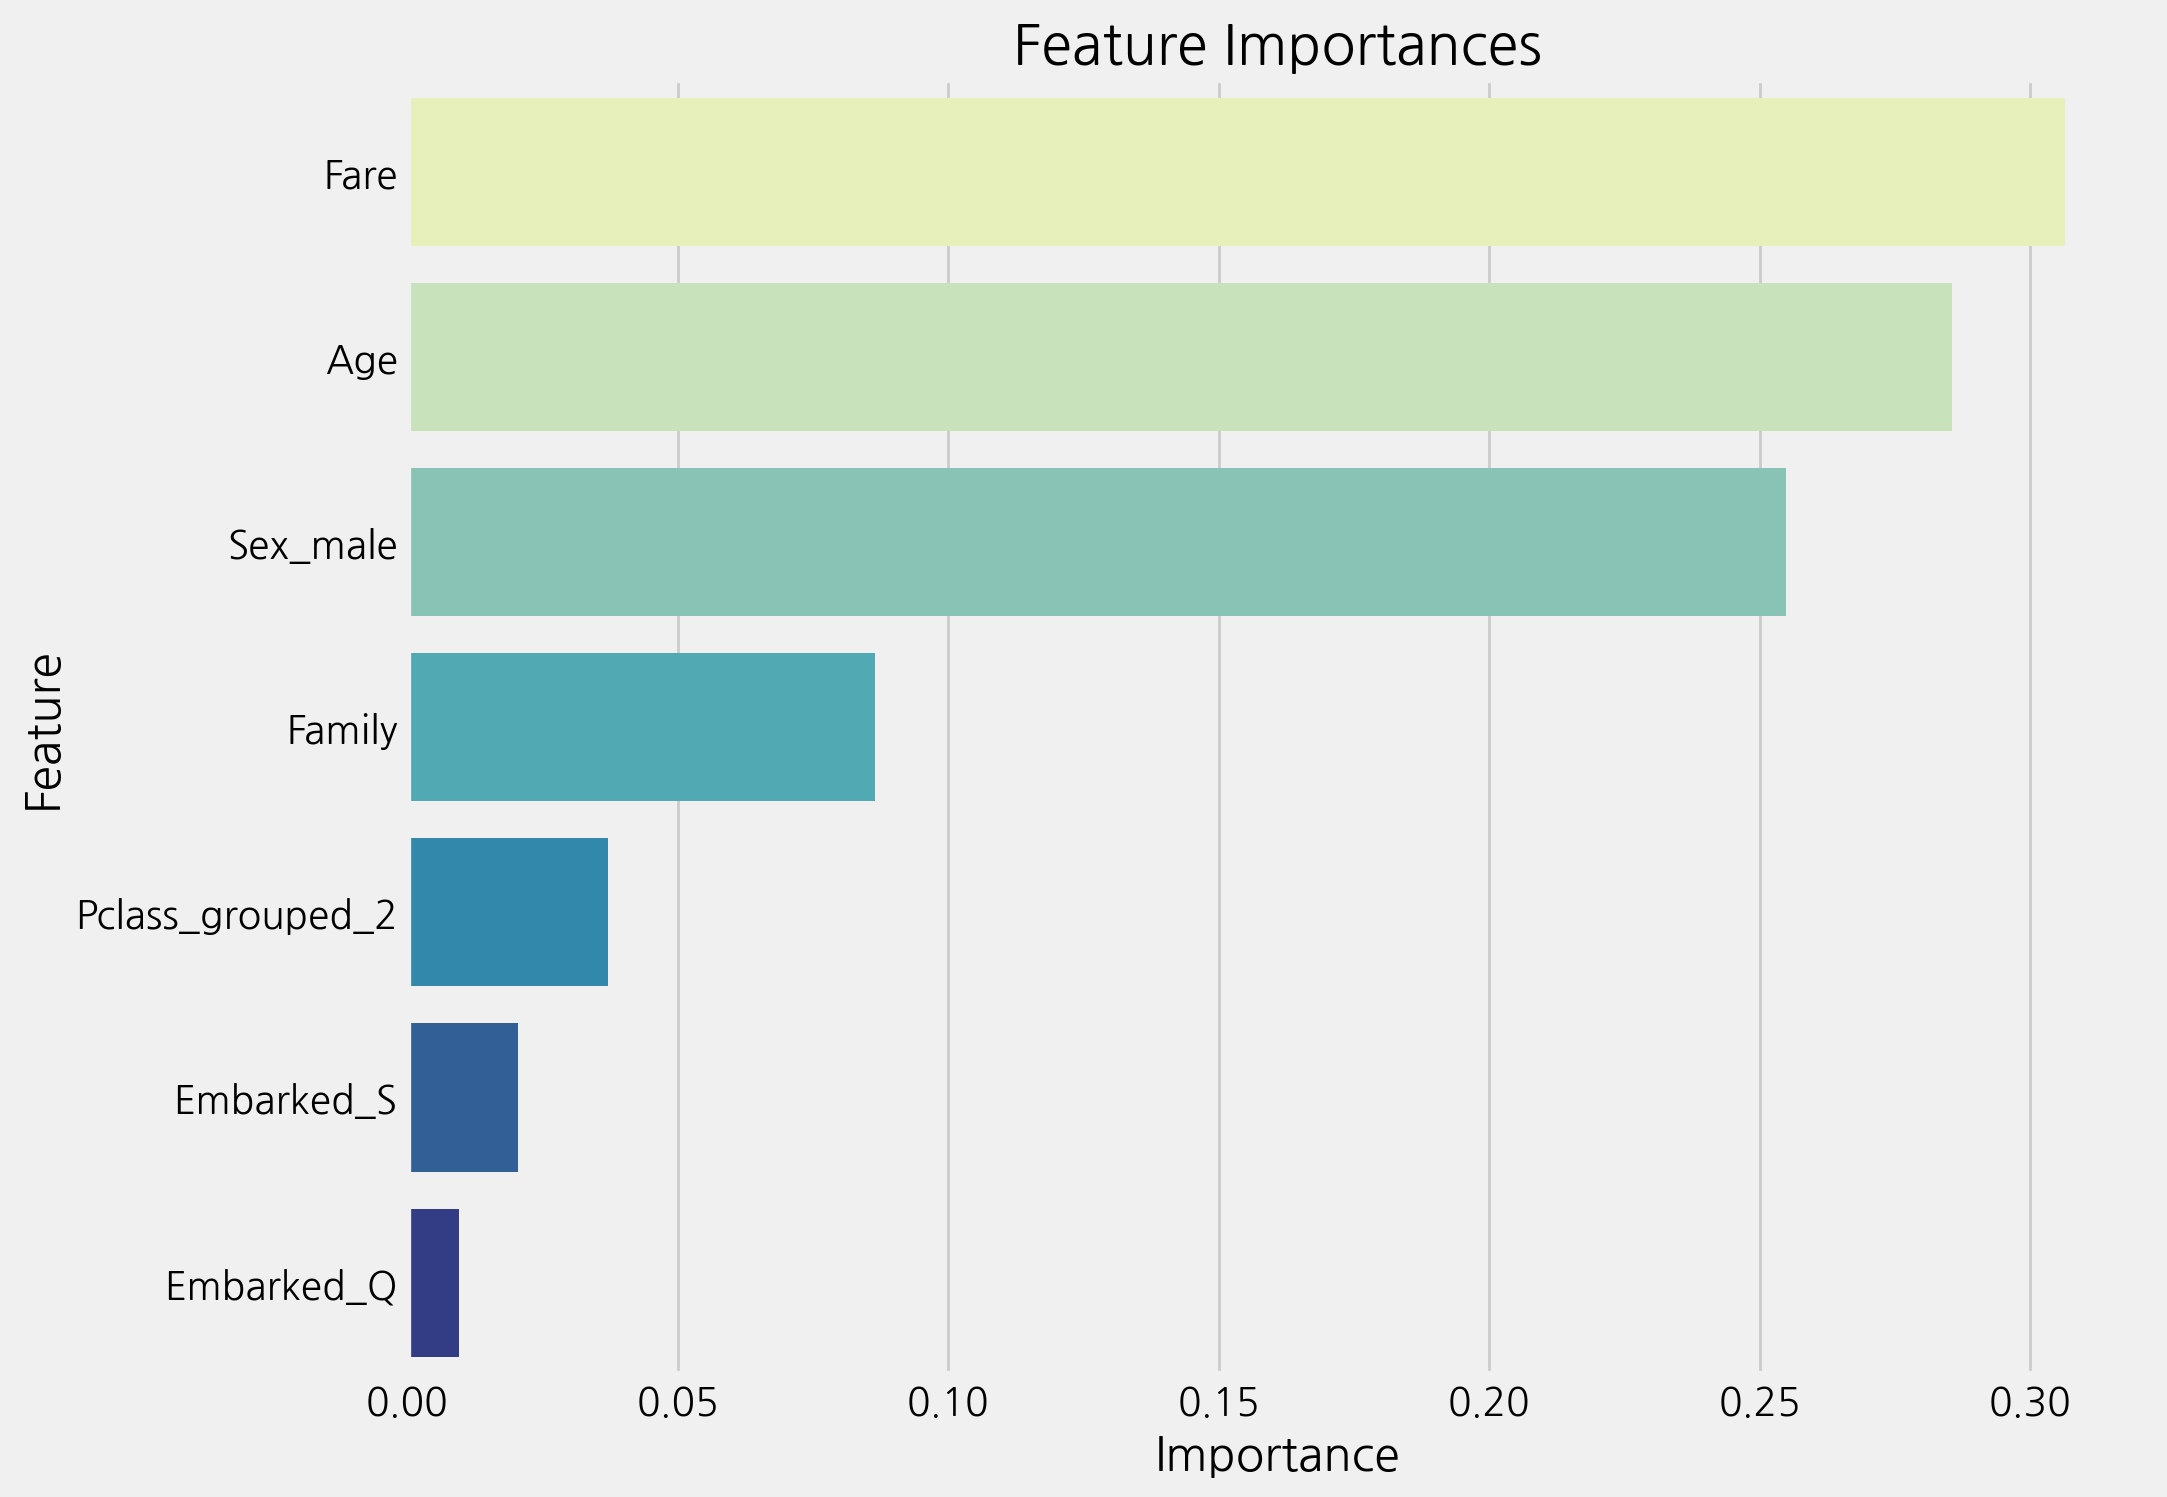

In [ ]:
# 특징 중요도 추출
feature_importances = model.feature_importances_
features = X_train.columns

# 중요도 시각화
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
})

# 중요도 순서로 정렬
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='YlGnBu')
plt.title('Feature Importances')
plt.show()

# test 파일 예측

In [ ]:
# test 결측치
missing_data = pd.DataFrame({
    "Missing Values": ori_test.isnull().sum(),
    "Percentage (%)": (ori_test.isnull().sum() / len(ori_test)) * 100
})
print(missing_data)

             Missing Values  Percentage (%)
PassengerId               0        0.000000
Pclass                    0        0.000000
Name                      0        0.000000
Sex                       0        0.000000
Age                      86       20.574163
SibSp                     0        0.000000
Parch                     0        0.000000
Ticket                    0        0.000000
Fare                      1        0.239234
Cabin                   327       78.229665
Embarked                  0        0.000000


### test 파일 전처리

In [ ]:
ori_test['Pclass_grouped'] = ori_test['Pclass'].apply(lambda x: 1 if x == 1 else 2)


In [ ]:
ori_test['Family'] = ori_test['SibSp'] + ori_test['Parch']

In [ ]:
test = ori_test.drop(['PassengerId', 'Pclass', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'], axis=1)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 스케일러 초기화
scaler = MinMaxScaler()

# 연속형 변수만 스케일링
test[['Age', 'Fare']] = scaler.fit_transform(test[['Age', 'Fare']])

In [ ]:
# 범주형 변수를 원-핫 인코딩
test = pd.get_dummies(test, columns=['Pclass_grouped', 'Embarked', 'Sex'], drop_first=True) #첫번째 범주를 드롭하여 다중공선성 문제 최소화
test
#scaled, encoding 완료되었습니다.

,Age,Fare,Family,Pclass_grouped_2,Embarked_Q,Embarked_S,Sex_male
0,0.452723,0.015282,0,True,True,False,True
1,0.617566,0.013663,1,True,False,True,False
2,0.815377,0.018909,0,True,True,False,True
3,0.353818,0.016908,0,True,False,True,True
4,0.287881,0.023984,2,True,False,True,False
...,...,...,...,...,...,...,...
413,NaN,0.015713,0,True,False,True,True
414,0.512066,0.212559,0,False,False,False,False
415,0.505473,0.014151,0,True,False,True,True
416,NaN,0.015713,0,True,False,True,True


In [ ]:
print(input_processed.columns)

Index(['Survived', 'Age', 'Fare', 'Family', 'Pclass_grouped_2', 'Embarked_Q',
       'Embarked_S', 'Sex_male'],
      dtype='object')


In [ ]:
print(test.columns)

Index(['Age', 'Fare', 'Family', 'Pclass_grouped_2', 'Embarked_Q', 'Embarked_S',
       'Sex_male'],
      dtype='object')


# 모델 학습과 예측

In [ ]:
### ✅ 내가 추가한 부분: 모델 학습과 예측
from sklearn.ensemble import RandomForestClassifier

# 학습용 데이터 준비
X_train = input_processed.drop('Survived', axis=1)
y_train = input_processed['Survived']

# 랜덤포레스트 모델 학습
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# test 데이터 예측
y_pred = model.predict(test)

### ✅ 내가 추가한 부분: 캐글 제출용 CSV 생성
# test 데이터에 PassengerId가 있다면 활용, 없으면 별도 관리 필요
# test_passenger_ids = test_df['PassengerId']

# 예시로 range로 PassengerId 임시 생성 (실제로는 test PassengerId 컬럼 써야 함)
submission = pd.DataFrame({
    'PassengerId': range(892, 892 + len(test)),  # 캐글 test.csv 기준 892부터 시작
    'Survived': y_pred
})

# CSV 저장
submission.to_csv('submission.csv', index=False)

print("✅ 캐글 제출용 submission.csv 저장 완료")


✅ 캐글 제출용 submission.csv 저장 완료


In [ ]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, cross_val_score

# LightGBM 모델 정의
lgb_model = lgb.LGBMClassifier(random_state=42, n_estimators=100)

# StratifiedKFold로 교차검증
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(lgb_model, X_train, y_train, cv=skf, scoring='accuracy')
print(f"LightGBM StratifiedKFold 평균 정확도: {scores.mean():.4f}")

# 전체 데이터로 학습
lgb_model.fit(X_train, y_train)

# test 예측
y_pred = lgb_model.predict(test)

# 제출 파일 생성
submission = pd.DataFrame({
    'PassengerId': range(892, 892 + len(test)),
    'Survived': y_pred
})
submission.to_csv('lgbm_submission.csv', index=False)
print("✅ LightGBM 캐글 제출용 lgbm_submission.csv 저장 완료")


In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(random_state=42, n_estimators=100, use_label_encoder=False, eval_metric='logloss')
scores = cross_val_score(xgb_model, X_train, y_train, cv=skf, scoring='accuracy')
print(f"XGBoost StratifiedKFold 평균 정확도: {scores.mean():.4f}")

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(test)

submission = pd.DataFrame({
    'PassengerId': range(892, 892 + len(test)),
    'Survived': y_pred
})
submission.to_csv('xgb_submission.csv', index=False)
print("✅ XGBoost 캐글 제출용 xgb_submission.csv 저장 완료")


XGBoost StratifiedKFold 평균 정확도: 0.8029
✅ XGBoost 캐글 제출용 xgb_submission.csv 저장 완료


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# 학습용 데이터 준비
X_train = input_processed.drop('Survived', axis=1)
y_train = input_processed['Survived']

# test 데이터는 미리 컬럼 맞춰서 준비된 상태라고 가정
# test = test.reindex(columns=X_train.columns, fill_value=0)

### ✅ n_estimators = 200
rf_200 = RandomForestClassifier(random_state=42, n_estimators=200)
rf_200.fit(X_train, y_train)
y_pred_200 = rf_200.predict(test)

submission_200 = pd.DataFrame({
    'PassengerId': range(892, 892 + len(test)),
    'Survived': y_pred_200
})
submission_200.to_csv('n_200_submission.csv', index=False)
print("✅ 랜덤포레스트 (n=200) 캐글 제출용 CSV 저장 완료: rf_200_submission.csv")

### ✅ n_estimators = 500
rf_500 = RandomForestClassifier(random_state=42, n_estimators=500)
rf_500.fit(X_train, y_train)
y_pred_500 = rf_500.predict(test)

submission_500 = pd.DataFrame({
    'PassengerId': range(892, 892 + len(test)),
    'Survived': y_pred_500
})
submission_500.to_csv('n_500_submission.csv', index=False)
print("✅ 랜덤포레스트 (n=500) 캐글 제출용 CSV 저장 완료: rf_500_submission.csv")


✅ 랜덤포레스트 (n=200) 캐글 제출용 CSV 저장 완료: rf_200_submission.csv
✅ 랜덤포레스트 (n=500) 캐글 제출용 CSV 저장 완료: rf_500_submission.csv


In [ ]:
submission_500['Survived'].value_counts()

,count
Survived,
0,286
1,132


n=500인 랜덤포레스트 모델에서 0.76555 점